# Lib Installation

In [1]:
!pip install  lightning pytorch-lightning torchvision  tqdm python-dotenv PyYAML wilds

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 14.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 4.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 3.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Cell 1: Install required libs (run in a cell)
!pip install lightning pytorch-lightning torchvision tqdm python-dotenv PyYAML wilds torchmetrics

# Config

In [35]:
config = {
    "algo": "FOND",
    "dataset": ["PACS", "VLCS", "OfficeHome", "Wilds"],  # Options: VLCS, PACS
    "test_set_id": 0,  # 0, 1, 2, or 3
    # Paths
    
    "data_dir": {"PACS":"/kaggle/input/pacs-dataset/kfold", "VLCS": "/kaggle/input/vlcsdataset/", "OfficeHome": "/kaggle/input/officehome/OfficeHome/", "Wilds": ""},
    "log_dir": "./logs",
    # Training settings
    "n_epochs": 5001,  # Converted from 5001 steps (~15 epochs at 32 batch size)
    "checkpoint_freq": 300,  # Evaluate every epoch (was 300 steps)
    "holdout_fraction": 0.2,
    # Model checkpointing
    "model_checkpoint": {
        "metric": "val/oacc",
        "maximize": True
    },
    # Seeds
    "overall_seed": 1,
    "trial_id": 0,
    "hparam_id": 0,  # 0=default hparams, 1-4=random variants
    # System
    "num_workers": 4,
    # Dataset config (from sweep)
    "overlap": "high",  # Must match PACS.OVERLAP_CONFIG keys
    "num_classes": None,
    "num_domain_linked_classes": None,
    # AutoFOND specific (disabled for baseline)
    "auto_augment": False,
    "augment_search_epochs": 5,
    "augment_policy_size": 5,
    "augment_num_policies": 3,
    # Teacher paths (empty for regular FOND)
    "teacher_paths": {}
    

}

In [36]:
config.update({
    "backbone": "clip_vit_b16",
    "pretrained": True,
    "freeze_backbone": True,   # IMPORTANT
    "feature_dim": 512,
})

In [12]:
!pip install git+https://github.com/openai/CLIP.git



  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-exx4xj7m
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-exx4xj7m
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=d5a6171d68715b18e727f1cf38604c2a15630d6ad149adf6aef57f77b1625298
  Stored in directory: /tmp/pip-ephem-wheel-cache-sv_d7ks7/wheels/3f/7c/a4/9b490845988bf7a4db33674d52f709f088f64392063872eb9a
Successfully built clip


# Imports

In [37]:
import math
from typing import List, Any, Dict, Optional, Callable, Tuple
import argparse
import logging
import hashlib
import numpy as np
from collections import Counter
import collections
import time
from datetime import datetime
import lightning as L
from tqdm import tqdm
import csv
import json
from pathlib import Path
import os
import torch
import torchmetrics
import torchvision.datasets.folder
from PIL import Image, ImageFile
from torch.utils.data import ConcatDataset, Dataset, Subset, TensorDataset
from torchvision import transforms
from torchvision.datasets import MNIST, ImageFolder
from torchvision.transforms.functional import rotate
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models
import clip
from wilds.datasets.camelyon17_dataset import Camelyon17Dataset





# SRC

## Domain Creation

In [39]:



def create_domains(
    num_classes: int, num_linked: int, num_train_domains: int
) -> List[List[int]]:
    """
    Determine and distribute domain-linked and domain-shared classes.
    Domain-linked classes will come from the same domain, i.e., idx=0.
    Domain-shared classes will exist in each of the remaining domains

    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_train_domains: number of different training domains
    """
    assert num_linked <= num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    domain_linked = [i for i in range(num_linked)]
    logging.info(f"Domain-shared classes: {domain_shared}")
    logging.info(f"Domain-linked classes: {domain_linked}")
    # domains = [domain_shared.copy() for i in range(num_train_domains)]
    domains = [[] for i in range(num_train_domains)]

    # first domain is domain-linked only
    domains[0] = domain_linked
    # other domains contain domain-shared only
    domains[1:] = [domain_shared.copy() for i in range(1, num_train_domains)]

    logging.info(f"domains[0]: {domains[0]}")
    logging.info(f"domains[1:]: {domains[1:]}")

    return domains


def create_domains_1(
    num_classes: int, num_linked: int, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_domains: number of different domains, including test domain
    """
    assert num_linked < num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    print(f"Shared classes: {domain_shared}")
    num_train_domains = num_domains - 1
    domains = [domain_shared.copy() for i in range(num_train_domains)]

    for class_idx in range(num_linked):
        domain_idx = class_idx % num_train_domains
        domains[domain_idx].append(class_idx)
    return domains


def create_domains_2(
    num_classes: int, num_linked_ratio: float, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked_ratio: ratio of linked classes to the total number of classes
        num_domains: number of different domains, including test domain
    """
    num_linked = math.floor(num_linked_ratio * num_classes)
    return create_domains_1(num_classes, num_linked, num_domains)



# Testing
create_domains(num_classes=10, num_linked=5, num_train_domains=3)
# Testing domain linked only
create_domains(num_classes=10, num_linked=10, num_train_domains=3)

# Testing same classes with different overlap
domains = create_domains_1(num_classes=10, num_linked=3, num_domains=4)
print(domains)
domains = create_domains_1(num_classes=10, num_linked=5, num_domains=4)
print(domains)

# Testing different classes with same overlap percentage
domains = create_domains_2(num_classes=10, num_linked_ratio=0.2, num_domains=4)
print(domains)
domains = create_domains_2(num_classes=5, num_linked_ratio=0.2, num_domains=4)
print(domains)


Shared classes: [3, 4, 5, 6, 7, 8, 9]
[[3, 4, 5, 6, 7, 8, 9, 0], [3, 4, 5, 6, 7, 8, 9, 1], [3, 4, 5, 6, 7, 8, 9, 2]]
Shared classes: [5, 6, 7, 8, 9]
[[5, 6, 7, 8, 9, 0, 3], [5, 6, 7, 8, 9, 1, 4], [5, 6, 7, 8, 9, 2]]
Shared classes: [2, 3, 4, 5, 6, 7, 8, 9]
[[2, 3, 4, 5, 6, 7, 8, 9, 0], [2, 3, 4, 5, 6, 7, 8, 9, 1], [2, 3, 4, 5, 6, 7, 8, 9]]
Shared classes: [1, 2, 3, 4]
[[1, 2, 3, 4, 0], [1, 2, 3, 4], [1, 2, 3, 4]]


## Hparams

In [40]:
"""
Hyper-parameter registry
"""


def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def _define_hparam(hparams, hparam_name, default_val, random_val_fn):
    hparams[hparam_name] = (hparams, hparam_name, default_val, random_val_fn)


def _hparams(algorithm, dataset, random_seed):
    """
    Global registry of hyperparams. Each entry is a (default, random) tuple.
    New algorithms / networks / etc. should add entries here.
    """
    SMALL_IMAGES = ["Debug28", "RotatedMNIST", "ColoredMNIST"]

    hparams = {}

    def _hparam(name, default_val, random_val_fn):
        """Define a hyperparameter. random_val_fn takes a RandomState and
        returns a random hyperparameter value."""
        assert name not in hparams
        random_state = np.random.RandomState(seed_hash(random_seed, name))
        hparams[name] = (default_val, random_val_fn(random_state))

    # Unconditional hparam definitions.

    _hparam("data_augmentation", True, lambda r: True)
    _hparam("resnet18", True, lambda r: True)
    _hparam("resnet_dropout", 0.0, lambda r: r.choice([0.0, 0.1, 0.5]))
    _hparam("class_balanced", False, lambda r: False)
    _hparam("nonlinear_classifier", False, lambda r: False)

    # Algorithm-specific hparam definitions. Each block of code below
    # corresponds to exactly one algorithm.

    if (
        algorithm == "FOND"
        or algorithm == "FOND_NC"
        or algorithm == "FOND_N"
        or algorithm == "NOC"
    ):
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))
    elif (
        algorithm == "FOND_Distillation_Separate_Projector"
        or algorithm == "FOND_Distillation_Teacher_Projector"
        or algorithm == "FOND_Distillation_Student_Projector"
    ):
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("distillation_temperature", 1, lambda r: r.uniform(1, 20))

    # Dataset-and-algorithm-specific hparam definitions. Each block of code
    # below corresponds to exactly one hparam. Avoid nested conditionals.

    if dataset in SMALL_IMAGES:
        _hparam("lr", 1e-3, lambda r: 10 ** r.uniform(-4.5, -2.5))
    else:
        _hparam("lr", 5e-5, lambda r: 10 ** r.uniform(-5, -3.5))

    if dataset in SMALL_IMAGES:
        _hparam("weight_decay", 0.0, lambda r: 0.0)
    else:
        _hparam("weight_decay", 0.0, lambda r: 10 ** r.uniform(-6, -2))

    if dataset in SMALL_IMAGES:
        _hparam("batch_size", 64, lambda r: int(2 ** r.uniform(3, 9)))
    elif algorithm == "ARM":
        _hparam("batch_size", 8, lambda r: 8)
    elif dataset == "DomainNet":
        _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5)))
    else:
        _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5.5)))

    return hparams


def default_hparams(algorithm, dataset):
    return {a: b for a, (b, c) in _hparams(algorithm, dataset, 0).items()}


def random_hparams(algorithm, dataset, seed):
    return {a: c for a, (b, c) in _hparams(algorithm, dataset, seed).items()}
    hparams.update({
    "backbone": "clip",
    "device": "cuda"
})



## Misc

In [41]:

class _SplitDataset(torch.utils.data.Dataset):
    """Used by split_dataset"""

    def __init__(self, underlying_dataset, keys):
        super(_SplitDataset, self).__init__()
        self.underlying_dataset = underlying_dataset
        self.keys = keys

    def __getitem__(self, key):
        return self.underlying_dataset[self.keys[key]]

    def __len__(self):
        return len(self.keys)


def split_dataset(dataset, n, seed=0):
    """
    Return a pair of datasets corresponding to a random split of the given
    dataset, with n datapoints in the first dataset and the rest in the last,
    using the given random seed
    """
    assert n <= len(dataset)
    keys = list(range(len(dataset)))
    np.random.RandomState(seed).shuffle(keys)
    keys_1 = keys[:n]
    keys_2 = keys[n:]
    return _SplitDataset(dataset, keys_1), _SplitDataset(dataset, keys_2)


def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def make_weights_for_balanced_classes(dataset):
    counts = Counter()
    classes = []
    for _, y in dataset:
        y = int(y)
        counts[y] += 1
        classes.append(y)

    n_classes = len(counts)

    weight_per_class = {}
    for y in counts:
        weight_per_class[y] = 1 / (counts[y] * n_classes)

    weights = torch.zeros(len(dataset))
    for i, y in enumerate(classes):
        weights[i] = weight_per_class[int(y)]

    return weights
def compute_loss(network, loader, device):
    """
    Compute average loss for a given loader.
    Returns: average loss value
    """
    total_loss = 0.0
    num_batches = 0
    
    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)
            
            # Compute loss
            loss = torch.nn.functional.cross_entropy(p, y, reduction='mean')
            total_loss += loss.item()
            num_batches += 1
    
    network.train()
    
    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    return avg_loss

def accuracy(network, loader, weights, device, dataset):
    correct = 0
    total = 0
    weights_offset = 0
    overlapping_classes = dataset.overlapping_classes
    num_classes = dataset.num_classes
    
    f1_score = torchmetrics.F1Score(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)
    per_class_accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average=None,
    ).to(device)
    accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    recall = torchmetrics.Recall(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    precision = torchmetrics.Precision(
        task='multiclass',  # ✅ Fixed typo
        num_classes=num_classes,
        average='macro'
    ).to(device)
    conf_mat = torchmetrics.ConfusionMatrix(
        task="multiclass",
        num_classes=num_classes
    ).to(device)  # ✅ Added .to(device)
    
    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)
            
            if weights is None:
                batch_weights = torch.ones(len(x))
            else:
                batch_weights = weights[weights_offset : weights_offset + len(x)]
                weights_offset += len(x)
            batch_weights = batch_weights.to(device)
            
            if p.size(1) == 1:
                correct += (
                    (p.gt(0).eq(y).float() * batch_weights.view(-1, 1)).sum().item()
                )
            else:
                correct += (p.argmax(1).eq(y).float() * batch_weights).sum().item()
            total += batch_weights.sum().item()
            
            # update metrics
            accuracy.update(p, y)
            recall.update(p, y)
            precision.update(p, y)
            f1_score.update(p, y)
            per_class_accuracy.update(p, y)
            conf_mat.update(p, y)
    
    network.train()
    compute_acc = accuracy.compute().item()
    compute_recall = recall.compute().item()
    compute_precision = precision.compute().item()  # ✅ Fixed typo
    compute_f1 = f1_score.compute().item()
    compute_per_class_acc = per_class_accuracy.compute().cpu().numpy()
    cm_compute = conf_mat.compute().cpu().numpy()  # ✅ Convert to numpy
    
    overlap_class_acc = []
    non_overlap_class_acc = []
    per_class_acc_dict = {}
    for i in range(num_classes):
        per_class_acc_dict[i] = float(compute_per_class_acc[i])
        if i in overlapping_classes:
            overlap_class_acc.append(compute_per_class_acc[i])
        else:
            non_overlap_class_acc.append(compute_per_class_acc[i])
    
    if len(non_overlap_class_acc) == 0:
        non_overlap_class_acc = -1
    else:
        non_overlap_class_acc = np.mean(non_overlap_class_acc)
    if len(overlap_class_acc) == 0:
        overlap_class_acc = -1
    else:
        overlap_class_acc = np.mean(overlap_class_acc)
    
    other_acc = correct / total
    
    return (
        float(compute_acc),
        float(compute_recall),
        float(compute_f1),
        float(compute_precision),      # ✅ Moved before oacc/nacc
        float(overlap_class_acc),
        float(non_overlap_class_acc),
        per_class_acc_dict,
        cm_compute
    )
class _InfiniteSampler(torch.utils.data.Sampler):
    """Wraps another Sampler to yield an infinite stream."""

    def __init__(self, sampler):
        self.sampler = sampler

    def __iter__(self):
        while True:
            for batch in self.sampler:
                yield batch


class InfiniteDataLoader:
    def __init__(self, dataset, weights, batch_size, num_workers):
        super().__init__()

        if weights is not None:
            sampler = torch.utils.data.WeightedRandomSampler(
                weights, replacement=True, num_samples=batch_size
            )
        else:
            sampler = torch.utils.data.RandomSampler(dataset, replacement=True)

        if weights == None:
            weights = torch.ones(len(dataset))

        batch_sampler = torch.utils.data.BatchSampler(
            sampler, batch_size=batch_size, drop_last=True
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

    def __iter__(self):
        while True:
            yield next(self._infinite_iterator)

    def __len__(self):
        raise ValueError


class FastDataLoader:
    """DataLoader wrapper with slightly improved speed by not respawning worker
    processes at every epoch."""

    def __init__(self, dataset, batch_size, num_workers):
        super().__init__()

        batch_sampler = torch.utils.data.BatchSampler(
            torch.utils.data.RandomSampler(dataset, replacement=False),
            batch_size=batch_size,
            drop_last=False,
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

        self._length = len(batch_sampler)

    def __iter__(self):
        for _ in range(len(self)):
            yield next(self._infinite_iterator)

    def __len__(self):
        return self._length


def config_logging():
    """
    Reusable code for formatting the logger
    """
    logging.basicConfig(
        format="%(asctime)s,%(msecs)03d %(levelname)-8s [%(filename)s:%(funcName)s:%(lineno)d] %(message)s",
        datefmt="%Y-%m-%d:%H:%M:%S",
        level=logging.INFO,
    )


## Simple Logger

In [42]:
"""
Simple CSV logger to replace W&B during development
Keeps the same interface for easy swap later
"""
class CSVLogger:
    """Lightweight logger that writes metrics to CSV"""
    
    def __init__(self, csv_path: str, root_dir:str=None):
        self.csv_path = Path(csv_path)
        self.csv_path.parent.mkdir(parents=True, exist_ok=True)
        self.fieldnames = None
        self.file = None
        self.writer = None
        self._init_csv()
        self.root = root_dir if root_dir is not None else csv_path.parent
    def _init_csv(self):
        """Initialize CSV file with headers"""
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = None  # Will be created on first log
    def return_root(self):
        return self.root
    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        """
        Log metrics to CSV
        
        Args:
            metrics: Dictionary of metric_name -> value
            step: Training step (optional, will be added if provided)
        """
        if step is not None:
            metrics = {"step": step, **metrics}
            
        # Flatten nested dictionaries (e.g., {"train/acc": 0.9})
        flat_metrics = {}
        for key, value in metrics.items():
            if isinstance(value, dict):
                for subkey, subvalue in value.items():
                    flat_metrics[f"{key}/{subkey}"] = subvalue
            else:
                flat_metrics[key] = value
        
        # Initialize writer with fieldnames on first call
        if self.writer is None:
            self.fieldnames = list(flat_metrics.keys())
            self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
            self.writer.writeheader()
            
        # Add new fields if they appear
        new_fields = set(flat_metrics.keys()) - set(self.fieldnames)
        if new_fields:
            self.fieldnames.extend(sorted(new_fields))
            # Rewrite file with new headers
            self.file.close()
            self._rewrite_with_new_fields(flat_metrics)
            return
            
        self.writer.writerow(flat_metrics)
        self.file.flush()  # Ensure immediate write
        
    def _rewrite_with_new_fields(self, new_row: Dict[str, Any]):
        """Rewrite CSV when new fields are discovered"""
        # Read existing rows
        with open(self.csv_path, 'r') as f:
            reader = csv.DictReader(f)
            existing_rows = list(reader)
        
        # Rewrite with updated fieldnames
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
        self.writer.writeheader()
        for row in existing_rows:
            self.writer.writerow(row)
        self.writer.writerow(new_row)
        self.file.flush()
        
    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        """Save experiment config as JSON"""
        if path is None:
            path = self.csv_path.parent / "config.json"
        with open(path, 'w') as f:
            json.dump(config, f, indent=2)
            
    def close(self):
        """Close CSV file"""
        if self.file:
            self.file.close()
            
    def __enter__(self):
        return self
        
    def __exit__(self, exc_type, exc_val, exc_tb):
        self.close()


class PrintLogger:
    """Even simpler logger that just prints to console"""
    
    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        step_str = f"[Step {step}] " if step is not None else ""
        metric_str = ", ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}" 
                               for k, v in metrics.items())
        print(f"{step_str}{metric_str}")
        
    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        print(f"Config: {json.dumps(config, indent=2)}")
        
    def close(self):
        pass


# DADA

In [43]:
import os, json, random, logging
import numpy as np
import torch
import torch.nn as nn

from torchvision import transforms
from torch.utils.data import DataLoader

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


In [44]:
class DiffGaussianNoise(nn.Module):
    def __init__(self, std=0.05):
        super().__init__()
        self.std = std

    def forward(self, x):
        if not self.training:
            return x
        noise = torch.randn_like(x) * self.std
        return x + noise


class DiffColorJitter(nn.Module):
    def __init__(self, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1):
        super().__init__()
        self.b = brightness
        self.c = contrast
        self.s = saturation
        self.h = hue

    def forward(self, img):
        if not self.training:
            return img

        if self.b > 0:
            img = img * (1 + torch.randn(1).item() * self.b)

        if self.c > 0:
            mean = img.mean(dim=[2,3], keepdim=True)
            img = (img - mean) * (1 + torch.randn(1).item() * self.c) + mean

        if self.s > 0:
            gray = img.mean(dim=1, keepdim=True)
            img = img + (img - gray) * (1 + torch.randn(1).item() * self.s)

        if self.h > 0:
            theta = torch.randn(1).item() * self.h
            u, w = torch.cos(torch.tensor(theta)), torch.sin(torch.tensor(theta))
            rot = torch.tensor([[u, -w, 0],[w, u, 0],[0, 0, 1]], device=img.device)
            img = torch.einsum('bchw,dc->bdhw', img, rot)

        return img


class DiffHSB(nn.Module):
    def __init__(self, hue=0.05, saturation=0.2, brightness=0.2):
        super().__init__()
        self.h = hue
        self.s = saturation
        self.b = brightness

    def forward(self, x):
        if not self.training:
            return x

        x = x * (1 + torch.randn(1).item() * self.h)
        x = torch.clamp(x, 0, 1)
        return x


class DiffAugment(nn.Module):
    def __init__(self):
        super().__init__()
        self.color = DiffColorJitter()
        self.hsb = DiffHSB()
        self.gauss = DiffGaussianNoise(0.03)

    def forward(self, x):
        x = self.color(x)
        x = self.hsb(x)
        x = self.gauss(x)
        return torch.clamp(x, 0, 1)


In [45]:
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, diff_aug):
        self.base = base_dataset
        self.diff_aug = diff_aug

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        if isinstance(x, torch.Tensor):
            x = self.diff_aug(x.unsqueeze(0)).squeeze(0)
        return x, y



In [46]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

diff_augment = DiffAugment().to(device)



In [47]:
def load_dataset(name, data_dir, domains, split, auto_augment):

    if name == "VLCS":
        dataset = VLCS(
            data_dir=data_dir,
            domains=domains,
            split=split,
            transform=base_transform
        )
    elif name == "PACS":
        dataset = PACS(
            data_dir=data_dir,
            domains=domains,
            split=split,
            transform=base_transform
        )
    elif name == "OfficeHome":
        dataset = OfficeHome(
            data_dir=data_dir,
            domains=domains,
            split=split,
            transform=base_transform
        )
    else:
        raise ValueError("Unknown dataset")

    #  DiffAugment ONLY for TRAIN
    if split == "train" and auto_augment:
        dataset = AugmentedDataset(dataset, diff_augment)

    return dataset



# CLIP wrapper

# Dataset

## Base

In [49]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

DATASETS2 = [
    # Debug
    "Debug28",
    "Debug224",
    # Small images
    "ColoredMNIST",
    "RotatedMNIST",
    # Big images
    "VLCS",
    "PACS",
    "OfficeHome",
    "TerraIncognita",
    "DomainNet",
    "SVIRO",
    # WILDS datasets
    "WILDSCamelyon",
    "WILDSFMoW",
    # Spawrious datasets
    "SpawriousO2O_easy",
    "SpawriousO2O_medium",
    "SpawriousO2O_hard",
    "SpawriousM2M_easy",
    "SpawriousM2M_medium",
    "SpawriousM2M_hard",
]

# OVERLAP_TYPES = ["none", "low", "mid", "high", "full", "0", "33", "66", "100"]
SPECIAL_OVERLAP_TYPES = ["0", "low", "high", "low_linked_only", "high_linked_only"]
OVERLAP_TYPES = ["0", "low", "high", "low_linked_only", "high_linked_only"]


def get_domain_classes(N_c, N_oc, repeat, N_s, seed):
    N_noc = N_c - N_oc
    Q = []
    C = list(range(N_c))

    random_state = np.random.RandomState(seed)

    # choose non overlapping classes
    C_noc = list(random_state.choice(C, replace=False, size=N_noc))
    C_oc = [x for x in C if x not in C_noc]

    # add to queue
    Q.extend(C_noc + list(np.repeat(C_oc, repeat)))

    # Round-robing distribution of classes
    domain_classes = [Q[i::N_s] for i in range(N_s)]

    # assert overlapping classes
    overlap = np.zeros(N_c)
    for cls_list in domain_classes:
        np.add.at(overlap, cls_list, 1)

    assert C_oc == list(np.where(overlap > 1)[0])

    # output
    print("C_noc", C_noc)
    print("C_oc", C_oc)
    print("Q", Q)
    print("domain_classes", domain_classes)

    return domain_classes


class DomainBedImageFolder(ImageFolder):
    """
    Custom class to allow class filtering
    """

    def __init__(
        self,
        root: str,
        transform: Optional[Callable] = None,
        target_transform: Optional[Callable] = None,
        remove_classes: List[int] = [],
        allowed_classes: List[int] = [],
        is_test_env: Optional[bool] = None,
        env_name: Optional[str] = None,
    ):
        super().__init__(root, transform, target_transform)

        # Remove specified classes
        old_samples = self.samples
        self.samples = []
        self.targets = []
        self.is_test_env = is_test_env
        self.allowed_classes = allowed_classes
        self.remove_classes = remove_classes
        self.env_name = env_name
        for sample in old_samples:
            _, target = sample

            if target not in remove_classes:
                self.samples.append(sample)
                self.targets.append(target)

        self.imgs = self.samples
        self.classes = list(set(self.targets))

    def __len__(self) -> int:
        return len(self.samples)

    def __str__(self):
        return (
            f"{self.env_name}: is_test_env={self.is_test_env}, allowed_classes={self.allowed_classes},"
            f" list(set(self.targets))={self.classes}, num_samples={len(self)}"
        )


def get_overlapping_classes(
    class_split: List[List[int]], num_classes: int
) -> List[int]:
    """
    Return the classes in multiple domains.
    """
    overlap = np.zeros(num_classes)
    for data in class_split:
        np.add.at(overlap, data, 1)

    overlapping_classes = list(np.where(overlap > 1)[0])

    return overlapping_classes


def get_dataset_class(dataset_name):
    """Return the dataset class with the given name."""
    if dataset_name not in globals():
        raise NotImplementedError("Dataset not found: {}".format(dataset_name))
    return globals()[dataset_name]


def num_environments(dataset_name):
    return len(get_dataset_class(dataset_name).ENVIRONMENTS)


class MultipleDomainDataset:
    N_STEPS = 5001  # Default, subclasses may override
    CHECKPOINT_FREQ = 100  # Default, subclasses may override
    N_WORKERS = 8  # Default, subclasses may override
    ENVIRONMENTS = None  # Subclasses should override
    INPUT_SHAPE = None  # Subclasses should override

    def __getitem__(self, index):
        return self.datasets[index]

    def __len__(self):
        return len(self.datasets)


class Debug(MultipleDomainDataset):
    def __init__(self, root, test_envs, hparams):
        super().__init__()
        self.input_shape = self.INPUT_SHAPE
        self.num_classes = 2
        self.datasets = []
        for _ in [0, 1, 2]:
            self.datasets.append(
                TensorDataset(
                    torch.randn(16, *self.INPUT_SHAPE),
                    torch.randint(0, self.num_classes, (16,)),
                )
            )


class Debug28(Debug):
    INPUT_SHAPE = (3, 28, 28)
    ENVIRONMENTS = ["0", "1", "2"]


class Debug224(Debug):
    INPUT_SHAPE = (3, 224, 224)
    ENVIRONMENTS = ["0", "1", "2"]


class MultipleEnvironmentMNIST(MultipleDomainDataset):
    def __init__(
        self,
        root,
        environments,
        dataset_transform,
        input_shape,
        num_classes,
        test_envs: List[int],
        domain_class_filter: List[List[int]],
    ):
        super().__init__()
        if root is None:
            raise ValueError("Data directory not specified!")

        original_dataset_tr = MNIST(root, train=True, download=True)
        original_dataset_te = MNIST(root, train=False, download=True)

        original_images = torch.cat(
            (original_dataset_tr.data, original_dataset_te.data)
        )

        original_labels = torch.cat(
            (original_dataset_tr.targets, original_dataset_te.targets)
        )

        shuffle = torch.randperm(len(original_images))

        original_images = original_images[shuffle]
        original_labels = original_labels[shuffle]

        assert len(test_envs) == 1, "Not performing leave-one-domain-out validation"
        num_envs = len(environments)

        self.num_classes = num_classes
        self.overlapping_classes = get_overlapping_classes(
            domain_class_filter, self.num_classes
        )

        # Dynamically associate a filter with a domain except for test_envs[0]
        num_filters = len(domain_class_filter)
        assert num_envs - 1 == num_filters  # b/c exempt first test env
        shift_filter = list(range(num_filters)) + list(range(num_filters))
        shift_filter = shift_filter[test_envs[0] : test_envs[0] + num_filters]

        self.datasets = []

        for i in range(len(environments)):
            images = original_images[i :: len(environments)]
            labels = original_labels[i :: len(environments)]
            self.datasets.append(dataset_transform(images, labels, environments[i]))

        self.input_shape = input_shape


class MultipleEnvironmentImageFolder(MultipleDomainDataset):
    def __init__(
        self,
        root,
        test_envs,
        augment,
        hparams,
        domain_class_filter: List[List[int]],
        num_classes=None,
    ):
        super().__init__()
        environments = [f.name for f in os.scandir(root) if f.is_dir()]
        environments = sorted(environments)
        num_envs = len(environments)

        assert len(test_envs) == 1, "Not performing leave-one-domain-out validation"

        self.idx_to_class = self.get_idx_to_class(
            os.path.join(root, environments[test_envs[0]])
        )
        self.num_classes = (
            len(self.idx_to_class) if num_classes is None else num_classes
        )

        self.overlapping_classes = get_overlapping_classes(
            domain_class_filter, self.num_classes
        )
        logging.info(f"Overlapping classes: {self.overlapping_classes}")

        # Dynamically associate a filter with a domain except for test_envs[0]
        num_filters = len(domain_class_filter)
        print(f"num_envs={num_envs}, num_filters={num_filters}, domain_class_filter={domain_class_filter}")
        assert num_envs - 1 == num_filters  # b/c exempt first test env
        shift_filter = list(range(num_filters)) + list(range(num_filters))
        shift_filter = shift_filter[test_envs[0] : test_envs[0] + num_filters]

        transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                   mean=[0.48145466, 0.4578275, 0.40821073],
                   std=[0.26862954, 0.26130258, 0.27577711],
                ),
            ]
        )

        augment_transform = transforms.Compose(
            [
                # transforms.Resize((224,224)),
                transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(0.3, 0.3, 0.3, 0.3),
                transforms.RandomGrayscale(),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.48145466, 0.4578275, 0.40821073],
                    std=[0.26862954, 0.26130258, 0.27577711],
                ),
            ]
        )

        self.datasets = []
        for i, environment in enumerate(environments):
            path = os.path.join(root, environment)

            # setup augmentation
            if augment and (i not in test_envs):
                env_transform = augment_transform
            else:
                env_transform = transform

            # setup class filtering
            all_classes = set(list(self.idx_to_class.keys()))
            if i not in test_envs:
                filter = domain_class_filter[shift_filter.pop()]
                if filter == []:
                    continue
                remove_classes = list(all_classes - set(filter))

                env_dataset = DomainBedImageFolder(
                    path,
                    transform=env_transform,
                    remove_classes=remove_classes,
                    is_test_env=False,
                    allowed_classes=filter,
                    env_name=environment,
                )
            else:
                remove_classes = list(range(self.num_classes, len(all_classes)))
                env_dataset = DomainBedImageFolder(
                    path,
                    transform=env_transform,
                    remove_classes=remove_classes,
                    is_test_env=True,
                    allowed_classes=list(range(self.num_classes)),
                    env_name=environment,
                )
                assert self.num_classes == len(env_dataset.classes)

            # print(f"\n[info] environment: {env_dataset.env_name}, classes: {env_dataset.allowed_classes}, is_test: {env_dataset.is_test_env}")
            logging.info(f"Created domain -> {env_dataset}")
            self.datasets.append(env_dataset)

        self.input_shape = (
            3,
            224,
            224,
        )

    def get_overlapping_classes(
        self, class_split: List[List[int]], num_classes: int
    ) -> List[int]:
        """
        Return the classes in multiple domains.
        """
        overlap = np.zeros(num_classes)
        for data in class_split:
            np.add.at(overlap, data, 1)

        overlapping_classes = list(np.where(overlap > 1)[0])

        return overlapping_classes

    def get_idx_to_class(self, data_dir: str) -> Dict[int, str]:
        dataset = ImageFolder(data_dir)
        idx_to_class = {}
        for key, value in dataset.class_to_idx.items():
            idx_to_class.update({value: key})

        assert len(dataset.class_to_idx) == len(
            idx_to_class
        ), "Class and labels are not one-to-one"

        return idx_to_class

## PACS

In [50]:

        )



## VLCS

## OfficeHome

In [52]:


class OfficeHome(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = sorted(["A", "C", "P", "R"])
    OVERLAP_CONFIG = {
        "0": [list(range(0, 22)), list(range(22, 44)), list(range(44, 65))],
        "low": [list(range(0, 30)), list(range(14, 44)), list(range(35, 65))],  # 25/65
        "high": [list(range(0, 38)), list(range(5, 44)), list(range(27, 65))],  # 50/65
        "low_linked_only": [
            list(range(0, 14)),
            list(range(30, 35)),
            list(range(44, 65)),
        ],
        "high_linked_only": [list(range(0, 5)), [], list(range(44, 65))],
        "100": [list(range(65)), list(range(65)), list(range(65))],
    }

    def __init__(
        self,
        root: str,
        test_envs: List[int],
        hparams: dict,
        num_classes: int,
        num_domain_linked_classes: int,
        overlap_type=None,
        overlap_seed=None,
    ):
        
        self.dir = root
        self._num_source_domains = 3
        self._num_classes = 65

        domain_class_filter = []
        if overlap_type is not None:
            logging.info(
                f"Using predefined class distributions: overlap_type={overlap_type}"
            )
            domain_class_filter = OfficeHome.OVERLAP_CONFIG[overlap_type]
        else:
            logging.info(
                f"Using dynamic class distributions: num_classes={num_classes}, num_linked={num_domain_linked_classes}, num_train_domains={self._num_source_domains}"
            )
            assert num_classes <= self._num_classes
            self._num_classes = num_classes
            domain_class_filter = create_domains(
                num_classes=num_classes,
                num_linked=num_domain_linked_classes,
                num_train_domains=self._num_source_domains,
            )
        print(f"DEBUG: overlap_type={overlap_type}")
        print(f"DEBUG: domain_class_filter={domain_class_filter}")
        print(f"DEBUG: len(domain_class_filter)={len(domain_class_filter)}")
        print(f"DEBUG: test_envs={test_envs}")


        super().__init__(
            self.dir,
            test_envs,
            hparams["data_augmentation"],
            hparams,
            domain_class_filter=domain_class_filter,
            num_classes=self._num_classes
        )


## Wilds

## INIT

In [53]:
DATASETS = {
    #"PACS": PACS,
   # "VLCS": VLCS,
    "OfficeHome": OfficeHome,
    #"WILDSCamelyon": WILDSCamelyon
}


# Networks

## Base


# new

In [24]:

class Identity(nn.Module):
    """An identity layer"""

    def __init__(self):
        super(Identity, self).__init__()

    def forward(self, x):
        return x


class ResNet(torch.nn.Module):
    """ResNet with the softmax chopped off and the batchnorm frozen"""

    def __init__(self, input_shape, hparams):
        """
        If you're using Compute Canada you will need to manually download
        and store the appropriate resnet18 and resnet50 weight files. Currently
        we are using:
            ResNet18_Weights.IMAGENET1K_V1
                "https://download.pytorch.org/models/resnet18-f37072fd.pth",
            ResNet50_Weights.IMAGENET1K_V2
                "https://download.pytorch.org/models/resnet50-11ad3fa6.pth",

        """
        super(ResNet, self).__init__()
        resnet18 = hparams["resnet18"]
        if resnet18:
            pretrain_weight = os.path.expanduser(
                "~/scratch/saved/resnet18-f37072fd.pth"
            )
            # assert os.path.isfile(pretrain_weight), f"File not found: {pretrain_weight}"
            if os.path.exists(pretrain_weight):
                print(
                    f"[info] loading weights resnet18: {resnet18}, from {pretrain_weight}"
                )
                self.network = torchvision.models.resnet18()
                self.network.load_state_dict(torch.load(pretrain_weight))
            else:
                self.network = torchvision.models.resnet18(
                    weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
                )

            self.n_outputs = 512
        else:
            pretrain_weight = os.path.expanduser(
                "~/scratch/saved/resnet50-11ad3fa6.pth"
            )
            # assert os.path.isfile(pretrain_weight), f"File not found: {pretrain_weight}"
            if os.path.exists(pretrain_weight):
                print(
                    f"[info] loading weights resnet50: {resnet18}, from {pretrain_weight}"
                )
                self.network = torchvision.models.resnet50()
                self.network.load_state_dict(torch.load(pretrain_weight))
            else:
                self.network = torchvision.models.resnet50(
                    weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2
                )

            self.n_outputs = 2048

        # self.network = remove_batch_norm_from_resnet(self.network)

        # adapt number of channels
        nc = input_shape[0]
        if nc != 3:
            tmp = self.network.conv1.weight.data.clone()

            self.network.conv1 = nn.Conv2d(
                nc, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
            )

            for i in range(nc):
                self.network.conv1.weight.data[:, i, :, :] = tmp[:, i % 3, :, :]

        # save memory
        del self.network.fc
        self.network.fc = Identity()

        self.freeze_bn()
        self.hparams = hparams
        self.dropout = nn.Dropout(hparams["resnet_dropout"])

    def forward(self, x):
        """Encode x into a feature vector of size n_outputs."""
        return self.dropout(self.network(x))

    def train(self, mode=True):
        """
        Override the default train() to freeze the BN parameters
        """
        super().train(mode)
        self.freeze_bn()

    def freeze_bn(self):
        for m in self.network.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()


def Featurizer(input_shape, hparams):
    """Auto-select an appropriate featurizer for the given input shape."""
    # if len(input_shape) == 1:
    #     return MLP(input_shape[0], hparams["mlp_width"], hparams)
    # elif input_shape[1:3] == (28, 28):
    #     return MNIST_CNN(input_shape)
    # elif input_shape[1:3] == (32, 32):
    #     return wide_resnet.Wide_ResNet(input_shape, 16, 2, 0.)
    # elif input_shape[1:3] == (224, 224):
    if input_shape[1:3] == (224, 224):
        return ResNet(input_shape, hparams)
    else:
        raise NotImplementedError


def Classifier(in_features, out_features, is_nonlinear=False):
    if is_nonlinear:
        return torch.nn.Sequential(
            torch.nn.Linear(in_features, in_features // 2),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features // 2, in_features // 4),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features // 4, out_features),
        )
    else:
        return torch.nn.Linear(in_features, out_features)


class Algorithm(torch.nn.Module):
    """
    A subclass of Algorithm implements a domain generalization algorithm.
    Subclasses should implement the following:
    - update()
    - predict()
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(Algorithm, self).__init__()
        self.hparams = hparams

    def update(self, minibatches, unlabeled=None):
        """
        Perform one update step, given a list of (x, y) tuples for all
        environments.

        Admits an optional list of unlabeled minibatches from the test domains,
        when task is domain_adaptation.
        """
        raise NotImplementedError

    def predict(self, x):
        raise NotImplementedError


class ERM(Algorithm):
    """
    Empirical Risk Minimization (ERM)
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(ERM, self).__init__(input_shape, num_classes, num_domains, hparams)
        self.featurizer = Featurizer(input_shape, self.hparams)
        self.classifier = Classifier(
            self.featurizer.n_outputs, num_classes, self.hparams["nonlinear_classifier"]
        )

        self.network = nn.Sequential(self.featurizer, self.classifier)
        self.optimizer = torch.optim.Adam(
            self.network.parameters(),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )

    def update(self, minibatches, unlabeled=None):
        all_x = torch.cat([x for x, y in minibatches])
        all_y = torch.cat([y for x, y in minibatches])
        loss = F.cross_entropy(self.predict(all_x), all_y)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {"loss": loss.item()}

    def predict(self, x):
        return self.network(x)


## Fond

In [56]:


class AbstractXDom(ERM):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(AbstractXDom, self).__init__(
            input_shape, num_classes, num_domains, hparams
        )

        self.domain_relations = hparams.get("domain_relations", None)

        self.temperature = hparams["temperature"]
        self.base_temperature = hparams["base_temperature"]

        encoder_output = 512 if hparams["resnet18"] else 2048
        self.projector = nn.Sequential(
            nn.Linear(encoder_output, encoder_output),
            nn.ReLU(),
            nn.Linear(encoder_output, 256),
        )

        def weight_init(m):
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        self.projector.apply(weight_init)

        self.optimizer = torch.optim.Adam(
            (
                list(self.featurizer.parameters())
                + list(self.classifier.parameters())
                + list(self.projector.parameters())
            ),
            lr=self.hparams["lr"],
            weight_decay=self.hparams["weight_decay"],
        )

    def get_masks(self, Y, D):
        """
        Generate masks relating samples and their domains/classes
        """
        # mask-out self-contrast cases
        self_mask = (~torch.eye(Y.shape[0], dtype=torch.bool)).to(Y.device)

        # mask out dot products between different classes
        same_Y_mask = torch.eq(Y.view(-1, 1), Y.view(-1, 1).T)
        # mask out dot products between different domains
        same_D_mask = torch.eq(D.view(-1, 1), D.view(-1, 1).T)

        return {
            "self_mask": self_mask,
            "same_class_mask": same_Y_mask,
            "same_class_exclude_self_mask": same_Y_mask * self_mask,
            "same_domain_mask": same_D_mask,
            "diff_domain_mask": ~same_D_mask,
            "diff_domain_same_class_mask": same_Y_mask * ~same_D_mask,
            "same_domain_diff_class_mask": ~same_Y_mask * same_D_mask,
            "same_domain_same_class_mask": same_Y_mask * same_D_mask,
        }

    def supcon_loss(
        self,
        projections,
        positive_mask,
        negative_mask,
        alpha: torch.Tensor,
        beta: torch.Tensor,
        epsilon: float = 1e-6,
    ):
        """
        Regular FOND_FBA Loss with custom masks for positive and A(i) "negative" samples
        """

        mean_positives_per_sample = (
            torch.count_nonzero(positive_mask) / projections.shape[0]
        )

        # count the number of samples with no positives
        num_zero_positives = projections.shape[0] - torch.count_nonzero(
            positive_mask.sum(1)
        )

        # proj_dot is cos similarity b/c features are normalized
        # find the dot product with respect to every x
        proj_dot = torch.div(torch.matmul(projections, projections.T), self.temperature)

        # for numeric stability so sum is never zero
        logits_max, _ = torch.max(proj_dot, dim=1, keepdim=True)
        logits = proj_dot - logits_max.detach()

        # compute exp per element (i.e. over each cosine similarity)
        exp_logits = torch.exp(logits) * negative_mask * beta
        # weigh intra domain negatives higher = same domain different class

        # decompose log(exp(x)/y) = x - log(y)
        # y = summation of cos similarities excluding self
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))

        # compute mean of log-likelihood over positives
        mean_log_prob_pos = (positive_mask * alpha * log_prob).sum(1) / (
            positive_mask.sum(1) + epsilon
        )

        loss = -(self.temperature / self.base_temperature) * mean_log_prob_pos
        loss = loss.mean()

        return loss, mean_positives_per_sample, num_zero_positives

    def preprocess(self, minibatches):
        # NOTE: current implementations doesn't create duplicates
        # check SelfReg

        num_domains = len(minibatches)
        features = [self.featurizer(xi) for xi, _ in minibatches]

        projections = [F.normalize(self.projector(fi)) for fi in features]
        classifs = [self.classifier(fi) for fi in features]
        targets = [yi for _, yi in minibatches]

        # create domain labels
        domains = [
            torch.zeros(len(x), dtype=torch.uint8).to(x.device) + i
            for i, x in enumerate(targets)
        ]

        # match domains
        if self.domain_relations is not None:
            for old, new in self.domain_relations.items():
                for d in domains:
                    d[d == old] = new

        return {
            "features": features,
            "projections": projections,
            "classifs": classifs,
            "targets": targets,
            "domains": domains,
            "num_domains": num_domains,
        }

    def update(self, minibatches, unlabeled=None):
        raise NotImplementedError()


class FONDBase(AbstractXDom):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FONDBase, self).__init__(input_shape, num_classes, num_domains, hparams)

        # hparams
        self.xdom_lmbd = hparams["xdom_lmbd"]
        self.error_lmbd = hparams["error_lmbd"]
        self.xda_alpha = hparams["xda_alpha"]
        self.xda_beta = hparams["xda_beta"]
        self.C_oc = hparams["C_oc"]

        # create class masks
        oc_weight = torch.zeros(num_classes, dtype=torch.bool)
        oc_weight[self.C_oc] = True
        noc_weight = ~oc_weight
        self.oc_weight = oc_weight.type(torch.float)
        self.noc_weight = noc_weight.type(torch.float)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)

        class_loss = F.cross_entropy(classifs, targets)

        loss = (
            class_loss
            + self.xdom_lmbd * xdom_loss
            + self.error_lmbd * torch.abs(error_loss)
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


class FOND(FONDBase):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND, self).__init__(input_shape, num_classes, num_domains, hparams)


class FOND_NC(FONDBase):
    """
    Based on FOND however we replace the fairness loss with the domain-linked
    classification loss
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_NC, self).__init__(input_shape, num_classes, num_domains, hparams)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)
        class_loss = F.cross_entropy(classifs, targets)
        if torch.isnan(noc_class_loss):
            noc_class_loss = torch.tensor(0).to(targets.device)

        loss = (
            class_loss + self.xdom_lmbd * xdom_loss + self.error_lmbd * noc_class_loss
        )

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "noc_class_loss": noc_class_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


# FOND with a non overlapping class loss, but no overall class loss
class FOND_N(FONDBase):
    """
    Guiding Question: Why optimize for domain-shared class accuracy if
    we are only interested in domain-linked classes? Does including domain-shared
    classes for the contrastive objective only improve domain-linked class
    performance?

    Based on FOND however we keep the domain-shared and domain-linked
    contrastive loss and only optimize for the domain-linked classification
    loss.
    """

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FOND_N, self).__init__(input_shape, num_classes, num_domains, hparams)

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)

        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(Y=targets, D=domains)

        alpha = (
            ~masks["diff_domain_same_class_mask"]
            + masks["diff_domain_same_class_mask"] * self.xda_alpha
        )

        beta = (
            ~masks["same_domain_diff_class_mask"]
            + masks["same_domain_diff_class_mask"] * self.xda_beta
        )

        xdom_loss, mean_positives_per_sample, num_zero_positives = self.supcon_loss(
            projections=projections,
            positive_mask=masks["same_class_mask"] * masks["self_mask"],
            negative_mask=masks["self_mask"],
            alpha=alpha,
            beta=beta,
        )

        oc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.oc_weight.to(targets.device)
        )
        noc_class_loss = F.cross_entropy(
            classifs, targets, weight=self.noc_weight.to(targets.device)
        )
        error_loss = oc_class_loss - noc_class_loss
        if torch.isnan(error_loss):
            error_loss = torch.tensor(0).to(targets.device)
        class_loss = F.cross_entropy(classifs, targets)
        if torch.isnan(noc_class_loss):
            noc_class_loss = torch.tensor(0).to(targets.device)

        loss = self.xdom_lmbd * xdom_loss + noc_class_loss

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "noc_class_loss": noc_class_loss.item(),
            "mean_p": mean_positives_per_sample.item(),
            "zero_p": num_zero_positives.item(),
        }


## Init

In [57]:


ALGORITHMS = {
    "ERM": ERM,
    "FOND": FOND,
    # "FOND_NC": "FOND_NC",
    # "FOND_N": "FOND_N",
    # "FOND_Distillation_Separate_Projector": "FOND_Distillation_Separate_Projector",
    # "FOND_Distillation_Teacher_Projector": "FOND_Distillation_Teacher_Projector",
    # "FOND_Distillation_Student_Projector": "FOND_Distillation_Student_Projector",
}


# Train

## Fit Simple

In [58]:
def fit_simple(
    exp_dir: str,
    logger,  # CSVLogger or PrintLogger
    seed: int,
    trial_seed: int,
    hparams_seed: int,
    algorithm_name: str,
    dataset_name: str,
    data_dir: str,
    num_workers: int,
    test_envs: list,
    overlap_type: str,
    holdout_fraction: float = 0.2,
    n_steps: int = 5001,  
    checkpoint_freq: int = 300,  
    model_checkpoint: Optional[Dict] = None,
    teacher_paths: Optional[Dict] = None,
    num_domain_linked_classes: Optional[int] = None,
    num_classes: Optional[int] = None,
    auto_augment: bool = False,
    augment_search_epochs: int = 10,
):
    # seed everything
    L.seed_everything(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # get device
    if torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"
    
    # Setup hyper parameters
    if hparams_seed == 0:
        hparams = default_hparams(algorithm_name, dataset_name)
    else:
        hparams = random_hparams(
            algorithm_name, dataset_name, seed_hash(hparams_seed, trial_seed)
        )
    logging.info(f"hparams: {hparams}")
   
    # Get dataset
    dataset = DATASETS[dataset_name](
        root=data_dir,
        test_envs=test_envs,
        hparams=hparams,
        overlap_type=overlap_type,
        num_classes=num_classes,
        num_domain_linked_classes=num_domain_linked_classes,
    )
    
    # get overlapping classes
    hparams["C_oc"] = dataset.overlapping_classes
    logging.info(f"Loaded {dataset_name}")
    
    # Split each env into an 'in-split' and an 'out-split'
    in_splits = []
    out_splits = []
    relative_test_env = None
    log_dir = logger.return_root()
    
    for env_i, env in enumerate(dataset):
        out, in_ = split_dataset(
            env, int(len(env) * holdout_fraction), seed_hash(trial_seed, env_i)
        )
        
        if hparams["class_balanced"]:
            in_weights = make_weights_for_balanced_classes(in_)
            out_weights = make_weights_for_balanced_classes(out)
        else:
            in_weights, out_weights = None, None
        
        in_splits.append((in_, in_weights))
        out_splits.append((out, out_weights))
        
        # determine the relative test env id
        if env.is_test_env:
            relative_test_env = env_i
    
    assert relative_test_env is not None, "No testing domains"
    logging.info(f"test_envs={test_envs}, relative_test_env={relative_test_env}")
    
    # Setup data loaders
    train_loaders = [
        InfiniteDataLoader(
            dataset=env,
            weights=env_weights,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for i, (env, env_weights) in enumerate(in_splits)
        if i != relative_test_env
    ]
    
    eval_loaders = [
        FastDataLoader(
            dataset=env,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for env, _ in (in_splits + out_splits)
    ]
    
    eval_weights = [None for _, weights in (in_splits + out_splits)]
    
    eval_loader_names = ["env{}_in".format(i) for i in range(len(in_splits))]
    eval_loader_names += ["env{}_out".format(i) for i in range(len(out_splits))]
    logging.info(f"Created data loaders:  {eval_loader_names}")
    
    train_minibatches_iterator = zip(*train_loaders)
    steps_per_epoch = min([len(env) / hparams["batch_size"] for env, _ in in_splits])
    
    # Setup the algorithm
    if "distillation" in algorithm_name.lower():
        assert len(test_envs) == 1
        teacher_path = teacher_paths[dataset_name][str(test_envs[0])]
        teacher_algorithm = torch.load(teacher_path, map_location=device)
        
        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
            teacher=teacher_algorithm,
        )
    else:
        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
        )
    
    algorithm.to(device)
    logging.info(f"Algorithm {algorithm_name} setup")
    
    # Calculate model statistics
    total_params = sum(p.numel() for p in algorithm.parameters())
    trainable_params = sum(p.numel() for p in algorithm.parameters() if p.requires_grad)
    
    # Calculate model size in MB
    param_size = sum(p.nelement() * p.element_size() for p in algorithm.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in algorithm.buffers())
    model_size_mb = (param_size + buffer_size) / (1024 ** 2)
    
    logging.info(f"Total parameters: {total_params:,}")
    logging.info(f"Trainable parameters: {trainable_params:,}")
    logging.info(f"Model size: {model_size_mb:.2f} MB")
    
    # Save model stats
    model_stats = {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "model_size_mb": model_size_mb,
        "dataset": dataset_name,
        "algorithm": algorithm_name,
    }
    
    import json
    with open(os.path.join(log_dir, "model_statistics.json"), "w") as f:
        json.dump(model_stats, f, indent=4)
    
    # Training loop
    logging.info(f"Begining training loop, with {steps_per_epoch} steps per epoch")
    checkpoint_vals = collections.defaultdict(lambda: [])
    
    # track the model checkpoint value
    best_model_checkpoint_value = None
    best_model_checkpoint_path = ""
    
    # get checkpoint parameters
    checkpoint_metric = model_checkpoint["metric"].split("/")
    stage, metric = checkpoint_metric[0], checkpoint_metric[1]
    print(f"Model checkpoint frequency: {checkpoint_freq}")
    
    # Initialize epoch-based tracking
    epoch_history = {
        "train": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "val": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "test": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "epochs": [],
        "epoch_times": [],
    }
    
    # Track training time
    training_start_time = time.time()
    epoch_start_time = time.time()
    current_epoch = 0
    steps_in_current_epoch = 0
    
    for step in tqdm(list(range(n_steps))):
        step_start_time = time.time()
        
        # Get batches
        minibatches_device = [
            (x.to(device), y.to(device)) for x, y in next(train_minibatches_iterator)
        ]
        
        # Perform an update
        step_vals = algorithm.update(minibatches_device, None)
        for key, val in step_vals.items():
            checkpoint_vals[key].append(val)
        
        # Track epochs
        steps_in_current_epoch += 1
        
        # Check if we've completed an epoch
        if steps_in_current_epoch >= steps_per_epoch:
            epoch_time = time.time() - epoch_start_time
            epoch_history["epoch_times"].append(epoch_time)
            current_epoch += 1
            steps_in_current_epoch = 0
            epoch_start_time = time.time()
        
        # log
        if (step % checkpoint_freq == 0) or (step == n_steps - 1):
            results_dict = {
                key: {
                    _key: []
                    for _key in ["acc", "f1", "nacc", "oacc", "recall", "precision", "cm", "loss"]
                    + [f"acc-{i}" for i in range(dataset.num_classes)]
                }
                for key in ["train", "val", "test", "other"]
            }
            
            # Calculate training value averages
            for key, val in checkpoint_vals.items():
                if np.isnan(np.mean(val)):
                    raise Exception(f"{key}: {np.mean(val)}")
                # Store the MEAN of training values, not the entire list
                results_dict["train"][str(key)] = [np.mean(val)]
            
            # Evaluation
            for name, loader, weights in zip(
                eval_loader_names,
                eval_loaders,
                eval_weights,
            ):
                # Compute metrics using existing accuracy function
                (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(
                    algorithm, loader, weights, device, dataset
                )
                
                # Compute loss separately
                loss = compute_loss(algorithm, loader, device)
                
                # env{domain_idx}_{rest_of_string} is how name is formatted
                domain_idx = int(name[3])
                
                loader_type = ""
                if domain_idx == relative_test_env:
                    if "in" in name:  # Note 'in' is the 80%
                        loader_type = "test"
                    else:
                        loader_type = "other"
                elif "out" in name:  # Note 'out' is the 20%
                    loader_type = "val"
                else:
                    loader_type = "train"
                
                # update results
                results_dict[loader_type]["acc"].append(float(acc))
                results_dict[loader_type]["recall"].append(float(recall))
                results_dict[loader_type]["f1"].append(float(f1))
                results_dict[loader_type]["precision"].append(float(precision))
                results_dict[loader_type]["nacc"].append(float(nacc))
                results_dict[loader_type]["oacc"].append(float(oacc))
                results_dict[loader_type]["cm"].append(cm)
                results_dict[loader_type]["loss"].append(float(loss))
                
                for class_id, class_acc in per_class_acc.items():
                    results_dict[loader_type]["acc-" + str(class_id)].append(class_acc)
            
            # Store epoch-level metrics
            current_epoch_num = step / steps_per_epoch
            epoch_history["epochs"].append(current_epoch_num)
            
            for split in ["train", "val", "test"]:
                if results_dict[split]["acc"]:
                    epoch_history[split]["acc"].append(np.mean(results_dict[split]["acc"]))
                    epoch_history[split]["precision"].append(np.mean(results_dict[split]["precision"]))
                    epoch_history[split]["recall"].append(np.mean(results_dict[split]["recall"]))
                    epoch_history[split]["f1"].append(np.mean(results_dict[split]["f1"]))
                    epoch_history[split]["loss"].append(np.mean(results_dict[split]["loss"]))
            
            # log metrics - using tqdm.write to avoid breaking progress bar
            tqdm.write(f"\n=== Step {step} (Epoch {current_epoch_num:.2f}) ===")
            tqdm.write(f"step_time: {time.time() - step_start_time:.4f}s")
            
            for stage in ["train", "val", "test", "other"]:
                if results_dict[stage]["acc"]:
                    tqdm.write(f"{stage.upper()}:")
                    tqdm.write(f"  loss: {np.mean(results_dict[stage]['loss']):.4f}")
                    tqdm.write(f"  acc: {np.mean(results_dict[stage]['acc']):.4f}")
                    tqdm.write(f"  precision: {np.mean(results_dict[stage]['precision']):.4f}")
                    tqdm.write(f"  recall: {np.mean(results_dict[stage]['recall']):.4f}")
                    tqdm.write(f"  f1: {np.mean(results_dict[stage]['f1']):.4f}")
                    tqdm.write(f"  oacc: {np.mean(results_dict[stage]['oacc']):.4f}")
                    tqdm.write(f"  nacc: {np.mean(results_dict[stage]['nacc']):.4f}")
            
            logger.log(results_dict, step)
            
            # Save model checkpoint
            if model_checkpoint is not None:
                # get checkpoint parameters
                checkpoint_metric = model_checkpoint["metric"].split("/")
                maximize = model_checkpoint["maximize"]
                stage, metric = checkpoint_metric[0], checkpoint_metric[1]
                
                # get current value
                current_model_checkpoint_value = np.nanmean(results_dict[stage][metric])
                ckpt_path = os.path.join(log_dir, f"{id}_model_step{step}.ckpt")
                
                if best_model_checkpoint_value == None:
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
                    torch.save(algorithm, ckpt_path)
                elif (
                    best_model_checkpoint_value < current_model_checkpoint_value
                ) and maximize:
                    torch.save(algorithm, ckpt_path)
                    # remove previous checkpoint
                    os.remove(best_model_checkpoint_path)
                    # update
                    logging.info(
                        "Updated {} from {} to {}".format(
                            model_checkpoint["metric"],
                            best_model_checkpoint_value,
                            current_model_checkpoint_value,
                        )
                    )
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
                elif (
                    best_model_checkpoint_value > current_model_checkpoint_value
                ) and not maximize:
                    torch.save(algorithm, ckpt_path)
                    # remove previous checkpoint
                    os.remove(best_model_checkpoint_path)
                    # update
                    logging.info(
                        "Updated {} from {} to {}".format(
                            model_checkpoint["metric"],
                            best_model_checkpoint_value,
                            current_model_checkpoint_value,
                        )
                    )
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
            
            checkpoint_vals = collections.defaultdict(lambda: [])
    
    # TRAINING COMPLETE - NOW PRINT EVERYTHING
    
    # Calculate total training time
    total_training_time = time.time() - training_start_time
    avg_epoch_time = np.mean(epoch_history["epoch_times"]) if epoch_history["epoch_times"] else 0
    
    print(f"\n{'='*60}")
    print(f"TRAINING COMPLETED")
    print(f"{'='*60}")
    print(f"Total training time: {total_training_time:.2f}s ({total_training_time/60:.2f} minutes)")
    print(f"Average time per epoch: {avg_epoch_time:.2f}s")
    print(f"Total epochs: {current_epoch}")
    print(f"{'='*60}\n")
    
    # Save training time statistics
    time_stats = {
        "total_training_time_seconds": total_training_time,
        "total_training_time_minutes": total_training_time / 60,
        "average_epoch_time_seconds": avg_epoch_time,
        "total_epochs": current_epoch,
        "epoch_times": epoch_history["epoch_times"],
    }
    
    with open(os.path.join(log_dir, "training_time_statistics.json"), "w") as f:
        json.dump(time_stats, f, indent=4)
    
    # Print and save final confusion matrices
    print("\n" + "="*60)
    print("FINAL EVALUATION - CONFUSION MATRICES")
    print("="*60)
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    for name, loader, weights in zip(eval_loader_names, eval_loaders, eval_weights):
        domain_idx = int(name[3])
        
        (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(
            algorithm, loader, weights, device, dataset
        )
        loss = compute_loss(algorithm, loader, device)
        
        # Determine split type
        if domain_idx == relative_test_env:
            if "in" in name:
                split_name = "TEST"
            else:
                split_name = "OTHER"
        elif "out" in name:
            split_name = "VAL"
        else:
            split_name = "TRAIN"
        
        print(f"\n{split_name} - {name}:")
        print(f"  Loss: {loss:.4f}")
        print(f"  Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        
        # Save confusion matrix as CSV
        cm_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.csv")
        np.savetxt(cm_path, cm, delimiter=",", fmt="%d")
        print(f"  Saved CSV to: {cm_path}")
        
        # Plot confusion matrix as heatmap
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                    cbar_kws={'label': 'Count'})
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)
        ax.set_title(f'Confusion Matrix - {split_name} - {name}', fontsize=14)
        
        # Save confusion matrix plot
        cm_plot_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.png")
        plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
        print(f"  Saved plot to: {cm_plot_path}")
        plt.show()
        plt.close()
    
    # Generate and save plots
    epochs = epoch_history["epochs"]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Training Curves - {dataset_name}', fontsize=16)
    
    # Plot 1: Accuracy
    ax = axes[0, 0]
    if epoch_history["train"]["acc"]:
        ax.plot(epochs, epoch_history["train"]["acc"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["acc"]:
        ax.plot(epochs, epoch_history["val"]["acc"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["acc"]:
        ax.plot(epochs, epoch_history["test"]["acc"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Loss
    ax = axes[0, 1]
    if epoch_history["train"]["loss"]:
        ax.plot(epochs, epoch_history["train"]["loss"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["loss"]:
        ax.plot(epochs, epoch_history["val"]["loss"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["loss"]:
        ax.plot(epochs, epoch_history["test"]["loss"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: F1 Score
    ax = axes[1, 0]
    if epoch_history["train"]["f1"]:
        ax.plot(epochs, epoch_history["train"]["f1"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["f1"]:
        ax.plot(epochs, epoch_history["val"]["f1"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["f1"]:
        ax.plot(epochs, epoch_history["test"]["f1"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 Score vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Precision and Recall
    ax = axes[1, 1]
    if epoch_history["val"]["precision"]:
        ax.plot(epochs, epoch_history["val"]["precision"], label='Val Precision', marker='s', linestyle='--', markersize=4)
    if epoch_history["val"]["recall"]:
        ax.plot(epochs, epoch_history["val"]["recall"], label='Val Recall', marker='o', linestyle='--', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title('Precision & Recall vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    plot_path = os.path.join(log_dir, f'training_curves_{dataset_name}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nTraining curves saved to: {plot_path}")
    plt.show()
    plt.close()
    
    # Create a separate plot for training time per epoch
    if epoch_history["epoch_times"]:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(range(1, len(epoch_history["epoch_times"]) + 1), 
                epoch_history["epoch_times"], marker='o', markersize=4)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Time (seconds)')
        ax.set_title(f'Training Time per Epoch - {dataset_name}')
        ax.grid(True, alpha=0.3)
        
        # Add average line
        avg_time = np.mean(epoch_history["epoch_times"])
        ax.axhline(y=avg_time, color='r', linestyle='--', 
                   label=f'Average: {avg_time:.2f}s')
        ax.legend()
        
        plt.tight_layout()
        time_plot_path = os.path.join(log_dir, f'epoch_times_{dataset_name}.png')
        plt.savefig(time_plot_path, dpi=300, bbox_inches='tight')
        print(f"Epoch time plot saved to: {time_plot_path}")
        plt.show()
        plt.close()
    
    # Save epoch history for later analysis
    with open(os.path.join(log_dir, "epoch_history.json"), "w") as f:
        history_serializable = {
            "epochs": epoch_history["epochs"],
            "epoch_times": epoch_history["epoch_times"],
        }
        for split in ["train", "val", "test"]:
            history_serializable[split] = {}
            for metric in ["loss", "acc", "precision", "recall", "f1"]:
                history_serializable[split][metric] = [
                    float(x) if not np.isnan(x) else None 
                    for x in epoch_history[split][metric]
                ]
        json.dump(history_serializable, f, indent=4)
    
    print(f"\nAll results saved to: {log_dir}")
    print(f"\nSummary of saved files:")
    print(f"  - model_statistics.json")
    print(f"  - training_time_statistics.json")
    print(f"  - epoch_history.json")
    print(f"  - training_curves_{dataset_name}.png")
    print(f"  - epoch_times_{dataset_name}.png")
    print(f"  - confusion_matrix_*.csv (for all splits)")
    print(f"  - confusion_matrix_*.png (heatmaps for all splits)")

# Train AutoFOND

## Setup

In [59]:
output_dir = "/kaggle/working/experiments"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
exp_name_oh = input()
config["name"] = exp_name_oh

exp_name_oh = config["name"] or f"{config['algo']}_{config['dataset']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
exp_dir = Path(output_dir) / exp_name_oh
exp_dir.mkdir(parents=True, exist_ok=True)
log_dir = exp_dir / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)
# Setup logging
config_logging()
logging.info(f"Starting experiment: {exp_name_oh}")
logging.info(f"Output directory: {exp_dir}")

# Save config to experiment directory
with open(exp_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)


logger = CSVLogger(log_dir / 'metrics.csv',  root_dir=log_dir)


 experiment_with_pacs_SimpleDiffAug_with clip


# DADA Train

# OfficeHome

In [61]:
config = {
    "data_dir": {
        "OfficeHome": "/kaggle/input/officehome",
        "VLCS": "/kaggle/input/vlcsdataset",
        "PACS": "/kaggle/input/pacs-dataset",
    },

    "algo": "ERM",
    "seed": 0,
    "trial_seed": 0,
    "hparams_seed": 0,
    "num_workers": 4,
    "test_set_id": 0,
    "num_classes": 65,   # OfficeHome
    "n_epochs": 5001,
    "auto_augment": True,
}

Seed set to 0


DEBUG: overlap_type=100
DEBUG: domain_class_filter=[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]]
DEBUG: len(domain_class_filter)=3
DEBUG: test_envs=[0]
num_envs=4, num_filters=3, domain_class_filter=[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:03<00:00, 14.8MB/s]


Model checkpoint frequency: 300



=== Step 0 (Epoch 0.00) ===
step_time: 196.6846s
TRAIN:
  loss: 4.3268
  acc: 0.0103
  precision: 0.0147
  recall: 0.0103
  f1: 0.0058
  oacc: 0.0103
  nacc: -1.0000
VAL:
  loss: 4.3098
  acc: 0.0118
  precision: 0.0054
  recall: 0.0118
  f1: 0.0064
  oacc: 0.0118
  nacc: -1.0000
TEST:
  loss: 4.3871
  acc: 0.0100
  precision: 0.0041
  recall: 0.0100
  f1: 0.0052


...


=== Step 4500 (Epoch 74.15) ===
step_time: 185.4312s
TRAIN:
  loss: 0.0578
  acc: 0.9839
  precision: 0.9841
  recall: 0.9839
  f1: 0.9835
  oacc: 0.9839
  nacc: -1.0000
VAL:
  loss: 1.1845
  acc: 0.7895
  precision: 0.8090
  recall: 0.7895
  f1: 0.7868
  oacc: 0.7895
  nacc: -1.0000
TEST:
  loss: 3.7475
  acc: 0.4505
  precision: 0.5481
  recall: 0.4505
  f1: 0.4453
  oacc: 0.4505
  nacc: -1.0000
OTHER:
  loss: 3.6907
  acc: 0.3956
  precision: 0.5073
  recall: 0.3956
  f1: 0.3927
  oacc: 0.3895
  nacc: -1.0000


 96%|█████████▌| 4801/5001 [1:41:36<3:06:05, 55.83s/it]


=== Step 4800 (Epoch 79.09) ===
step_time: 184.6615s
TRAIN:
  loss: 0.0399
  acc: 0.9873
  precision: 0.9874
  recall: 0.9873
  f1: 0.9871
  oacc: 0.9873
  nacc: -1.0000
VAL:
  loss: 1.1978
  acc: 0.7807
  precision: 0.7968
  recall: 0.7807
  f1: 0.7745
  oacc: 0.7807
  nacc: -1.0000
TEST:
  loss: 3.3451
  acc: 0.4974
  precision: 0.5315
  recall: 0.4974
  f1: 0.4843
  oacc: 0.4974
  nacc: -1.0000
OTHER:
  loss: 3.0287
  acc: 0.4693
  precision: 0.5167
  recall: 0.4693
  f1: 0.4518
  oacc: 0.4621
  nacc: -1.0000


100%|██████████| 5001/5001 [1:46:44<00:00,  1.28s/it]  



=== Step 5000 (Epoch 82.39) ===
step_time: 184.0268s
TRAIN:
  loss: 0.0423
  acc: 0.9860
  precision: 0.9882
  recall: 0.9860
  f1: 0.9868
  oacc: 0.9860
  nacc: -1.0000
VAL:
  loss: 1.1114
  acc: 0.7851
  precision: 0.7990
  recall: 0.7851
  f1: 0.7796
  oacc: 0.7851
  nacc: -1.0000
TEST:
  loss: 3.2075
  acc: 0.4750
  precision: 0.5282
  recall: 0.4750
  f1: 0.4706
  oacc: 0.4750
  nacc: -1.0000
OTHER:
  loss: 3.3002
  acc: 0.4432
  precision: 0.5020
  recall: 0.4432
  f1: 0.4352
  oacc: 0.4432
  nacc: -1.0000

TRAINING COMPLETED
Total training time: 6404.04s (106.73 minutes)
Average time per epoch: 76.35s
Total epochs: 81


FINAL EVALUATION - CONFUSION MATRICES

TEST - env0_in:
  Loss: 3.2077
  Accuracy: 0.4750, Precision: 0.5282, Recall: 0.4750, F1: 0.4706
  Saved CSV to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_TEST_env0_in.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confu

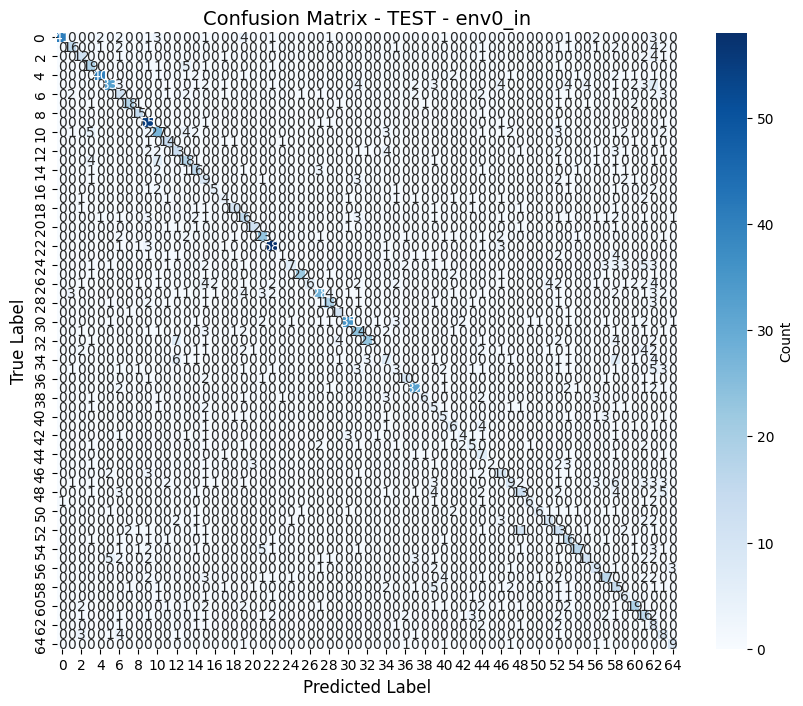


TRAIN - env1_in:
  Loss: 0.0587
  Accuracy: 0.9777, Precision: 0.9809, Recall: 0.9777, F1: 0.9788
  Saved CSV to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_TRAIN_env1_in.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_TRAIN_env1_in.png


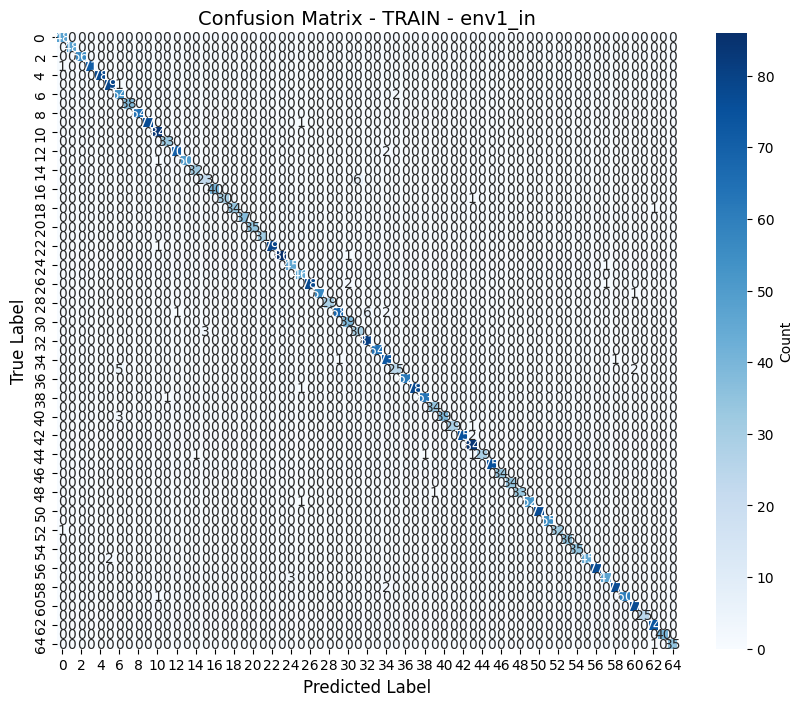


TRAIN - env2_in:
  Loss: 0.0296
  Accuracy: 0.9907, Precision: 0.9904, Recall: 0.9907, F1: 0.9903
  Saved CSV to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_TRAIN_env2_in.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_TRAIN_env2_in.png


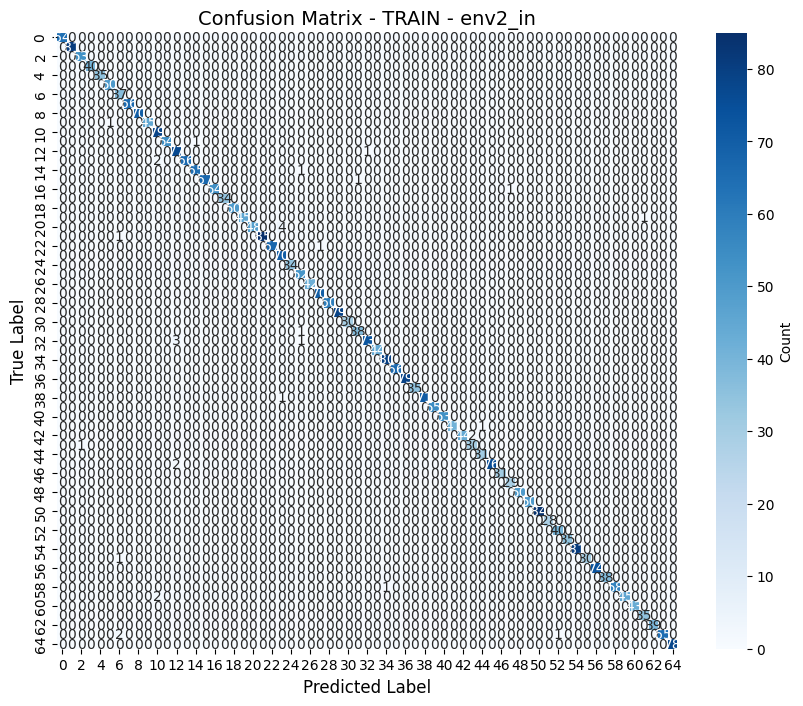


TRAIN - env3_in:
  Loss: 0.0309
  Accuracy: 0.9921, Precision: 0.9928, Recall: 0.9921, F1: 0.9923
  Saved CSV to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_TRAIN_env3_in.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_TRAIN_env3_in.png


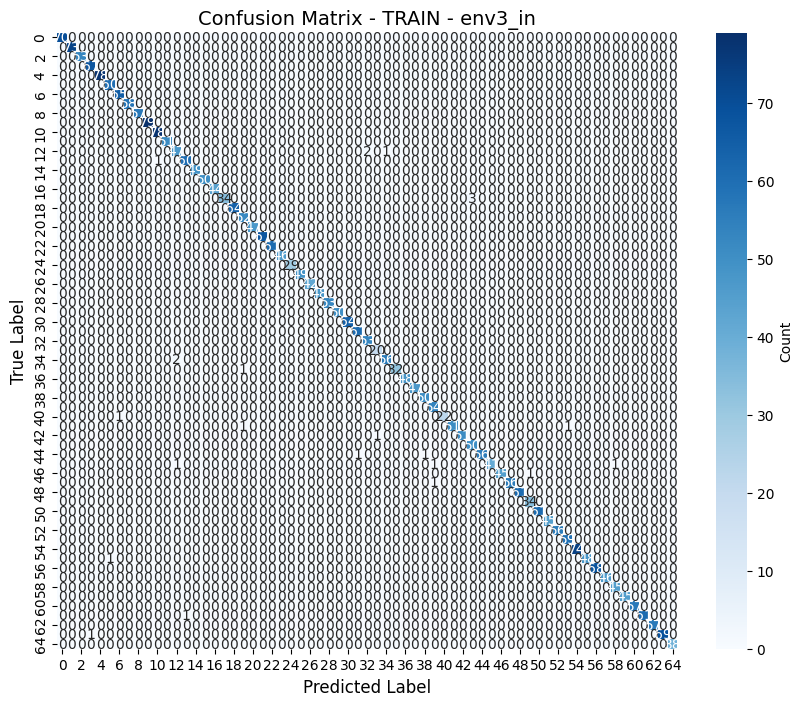


OTHER - env0_out:
  Loss: 3.2028
  Accuracy: 0.4432, Precision: 0.5020, Recall: 0.4432, F1: 0.4352
  Saved CSV to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_OTHER_env0_out.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_OTHER_env0_out.png


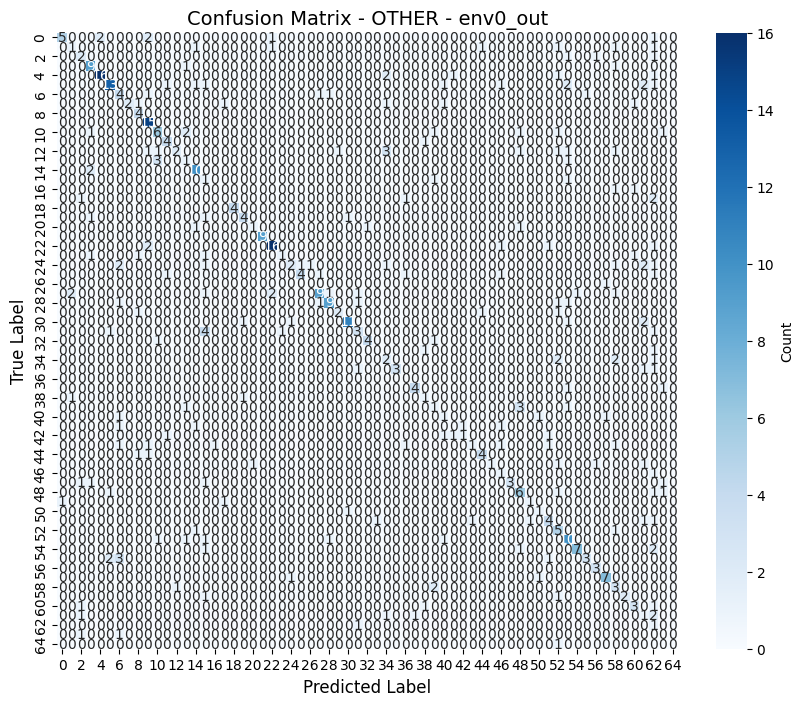


VAL - env1_out:
  Loss: 1.4577
  Accuracy: 0.7727, Precision: 0.7799, Recall: 0.7727, F1: 0.7639
  Saved CSV to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_VAL_env1_out.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_VAL_env1_out.png


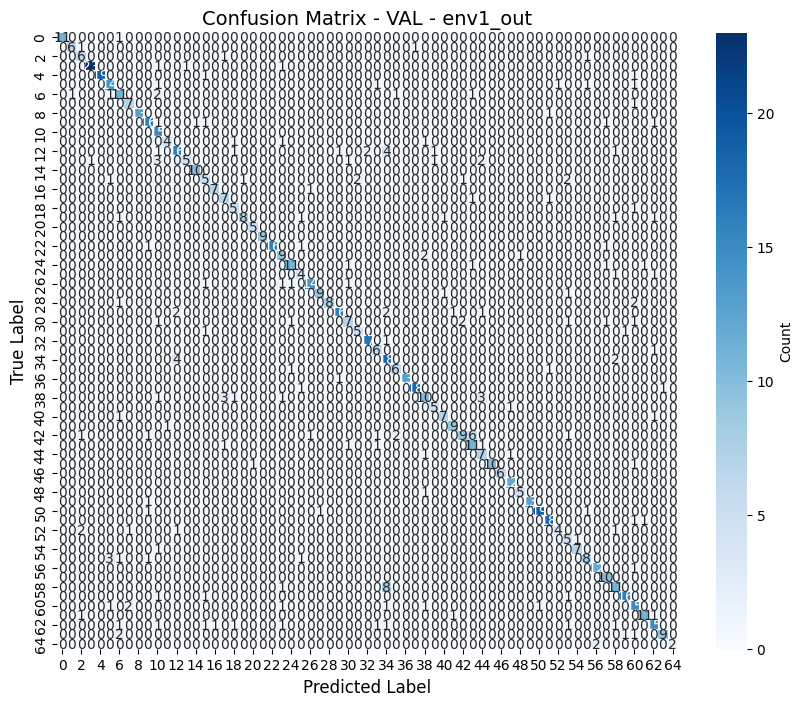


VAL - env2_out:
  Loss: 0.7874
  Accuracy: 0.8490, Precision: 0.8548, Recall: 0.8490, F1: 0.8424
  Saved CSV to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_VAL_env2_out.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_VAL_env2_out.png


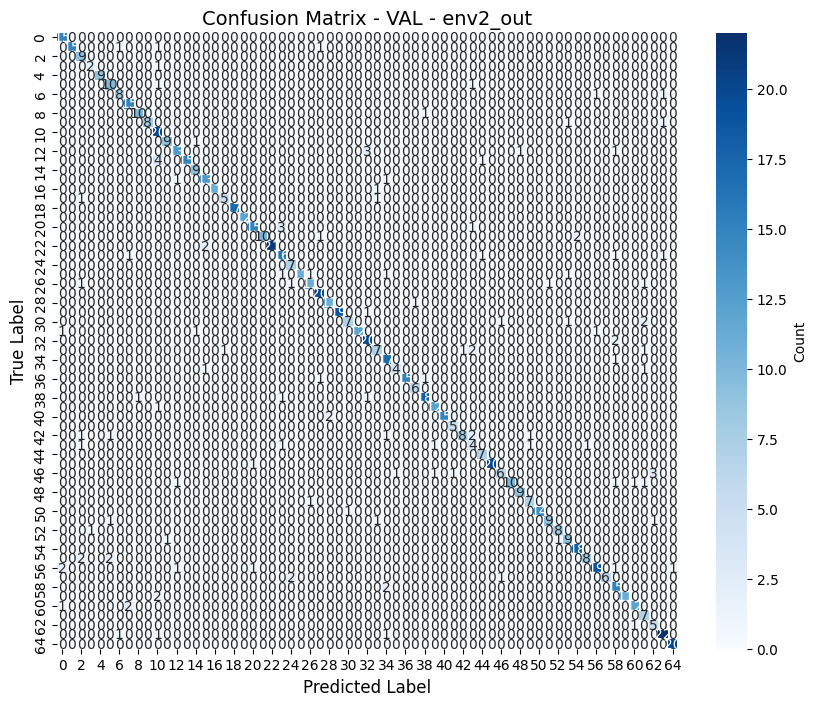


VAL - env3_out:
  Loss: 1.1894
  Accuracy: 0.7347, Precision: 0.7573, Recall: 0.7347, F1: 0.7345
  Saved CSV to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_VAL_env3_out.csv
  Saved plot to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/confusion_matrix_VAL_env3_out.png


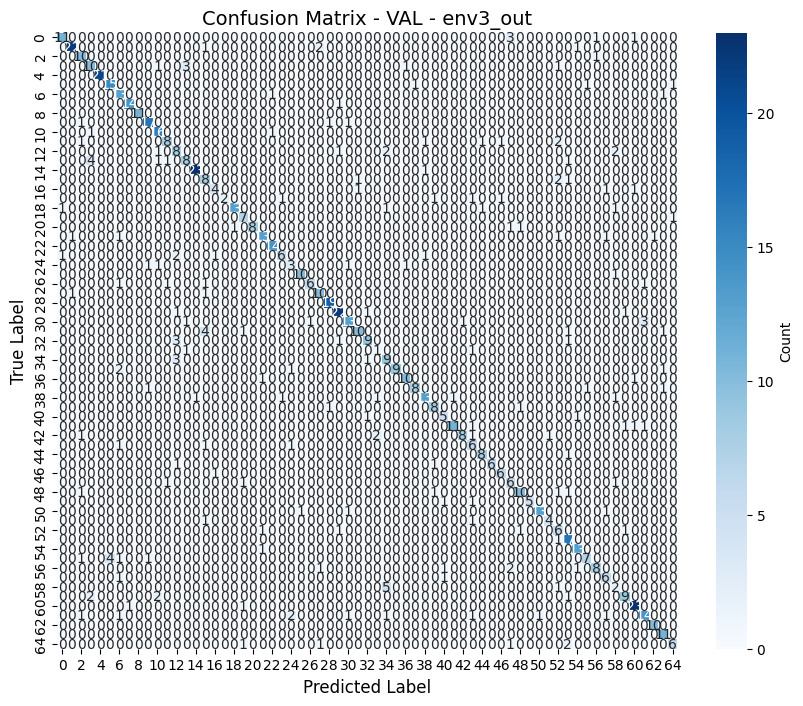


Training curves saved to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/training_curves_OfficeHome.png


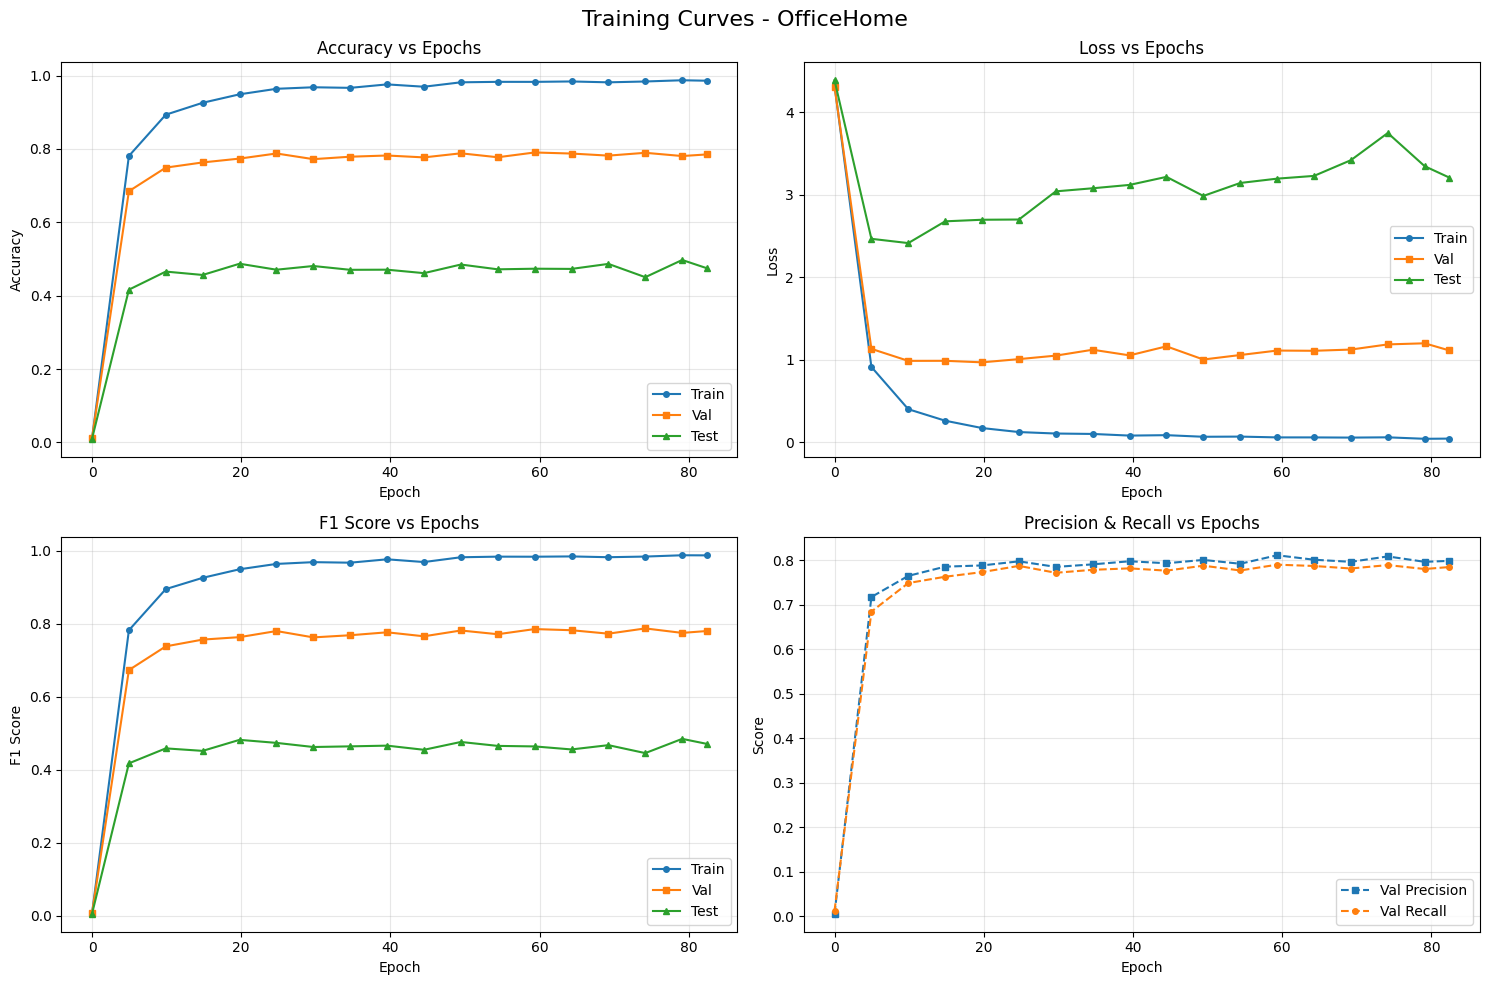

Epoch time plot saved to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs/epoch_times_OfficeHome.png


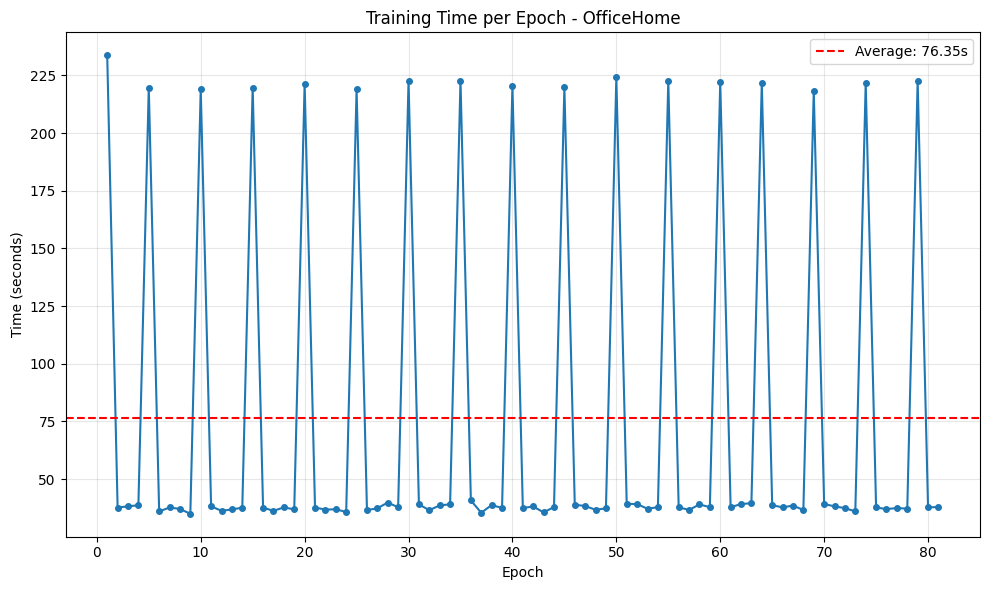


All results saved to: /kaggle/working/experiments/experiment_with_pacs_SimpleDiffAug_with clip/logs

Summary of saved files:
  - model_statistics.json
  - training_time_statistics.json
  - epoch_history.json
  - training_curves_OfficeHome.png
  - epoch_times_OfficeHome.png
  - confusion_matrix_*.csv (for all splits)
  - confusion_matrix_*.png (heatmaps for all splits)


In [62]:
fit_simple(
    exp_dir=str(exp_dir),
    logger=logger,

    seed=0,
    trial_seed=0,
    hparams_seed=0,

    algorithm_name="ERM",
    dataset_name="OfficeHome",
    data_dir="/kaggle/input/officehome/OfficeHome",

    num_workers=4,
    test_envs=[0],
    overlap_type="100",

    holdout_fraction=0.2,
    n_steps=5001,
    checkpoint_freq=300,

    #  THIS FIX
    model_checkpoint={
        "metric": "val/acc",
        "maximize": True
    },

    num_classes=65,

    auto_augment=True,
    augment_search_epochs=10,
)

In [40]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets
import optuna
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Seeds
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)



Device: cuda


In [50]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, Dataset
import torch

DATA_DIR = "/kaggle/input/officehome/OfficeHome"
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# DiffAugment / AugmentedDataset should already be defined

def load_officehome_dataset(split="train", aug_strength=0.2, auto_augment=False, val_ratio=0.2, seed=0):
    """
    Load OfficeHome dataset and split manually into train/val
    """
    # ImageFolder automatically reads all class subfolders (Art, Clipart, Product, RealWorld)
    full_dataset = ImageFolder(root=DATA_DIR, transform=base_transform)
    
    # Split train / val
    total_len = len(full_dataset)
    val_len = int(total_len * val_ratio)
    train_len = total_len - val_len
    
    generator = torch.Generator().manual_seed(seed)
    train_dataset, val_dataset = random_split(full_dataset, [train_len, val_len], generator=generator)
    
    if split=="train":
        dataset = train_dataset
        if auto_augment:
            diff_augment = DiffAugment(aug_strength=aug_strength).to(device)
            dataset = AugmentedDataset(dataset, diff_augment)
    else:
        dataset = val_dataset
    
    return dataset




In [51]:
def objective(trial):
    # --- Hyperparameters ---
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    aug_strength = trial.suggest_float("aug_strength", 0.05, 0.3)
    scheduler_name = trial.suggest_categorical("scheduler", ["StepLR", "CosineAnnealingLR"])
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    
    # --- Load data ---
    train_dataset = load_officehome_dataset(split="train", aug_strength=aug_strength)
    val_dataset = load_officehome_dataset(split="val", auto_augment=False)

    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    # --- Model ---
    model = models.resnet18(pretrained=True)
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(model.fc.in_features, 65)
    )
    model = model.to(device)
    
    # --- Optimizer ---
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    
    # --- Scheduler ---
    if scheduler_name == "StepLR":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    else:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
    
    # --- Loss ---
    criterion = nn.CrossEntropyLoss()
    
    # --- Training loop (small for tuning) ---
    best_val_acc = 0
    for epoch in range(3):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(x)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
        scheduler.step()
        
        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                y_hat = model(x)
                correct += (y_hat.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            
    return best_val_acc


In [52]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("Best Hyperparameters:")
print(study.best_params)



[I 2025-12-16 14:51:25,925] A new study created in memory with name: no-name-83ceaed5-55c3-43c2-bebd-9a737e331ae2
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 150MB/s] 
[I 2025-12-16 14:56:39,722] Trial 0 finished with value: 0.6143727943535451 a

Best Hyperparameters:
{'lr': 0.0006238388477893481, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.006680412938745798, 'aug_strength': 0.071293155782767, 'scheduler': 'CosineAnnealingLR', 'dropout': 0.11836243738921576}


In [54]:
best = study.best_params
print("Best Hyperparameters:", best)
# Example output:
# {'lr': 0.0001, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1e-5, 
#  'aug_strength': 0.15, 'scheduler': 'CosineAnnealingLR', 'dropout': 0.2}


Best Hyperparameters: {'lr': 0.0006238388477893481, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.006680412938745798, 'aug_strength': 0.071293155782767, 'scheduler': 'CosineAnnealingLR', 'dropout': 0.11836243738921576}


In [55]:
# Load datasets with best hyperparameters
train_dataset = load_officehome_dataset(split="train", aug_strength=best["aug_strength"])
val_dataset   = load_officehome_dataset(split="val", auto_augment=False)
test_dataset  = val_dataset  # Replace with separate test set if available

train_loader = DataLoader(train_dataset, batch_size=best["batch_size"], shuffle=True, num_workers=4)
val_loader   = DataLoader(val_dataset, batch_size=best["batch_size"], shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset, batch_size=best["batch_size"], shuffle=False, num_workers=4)


In [56]:
model = models.resnet18(pretrained=True)
model.fc = nn.Sequential(
    nn.Dropout(best["dropout"]),
    nn.Linear(model.fc.in_features, 65)
)
model = model.to(device)

if best["optimizer"] == "Adam":
    optimizer = torch.optim.Adam(model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"])
else:
    optimizer = torch.optim.SGD(model.parameters(), lr=best["lr"], momentum=0.9, weight_decay=best["weight_decay"])

if best["scheduler"] == "StepLR":
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
else:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

criterion = nn.CrossEntropyLoss()


In [57]:
train_acc_list, val_acc_list, test_acc_list = [], [], []
train_loss_list, val_loss_list, test_loss_list = [], [], []

num_epochs = 10
for epoch in range(num_epochs):
    # ===== TRAIN =====
    model.train()
    running_loss, correct, total = 0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_hat = model(x)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)
        correct += (y_hat.argmax(1)==y).sum().item()
        total += y.size(0)
    train_loss = running_loss / total
    train_acc = correct / total
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)
    scheduler.step()

    # ===== VALIDATION =====
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            y_hat = model(x)
            loss = criterion(y_hat, y)
            running_loss += loss.item() * y.size(0)
            correct += (y_hat.argmax(1)==y).sum().item()
            total += y.size(0)
    val_loss = running_loss / total
    val_acc = correct / total
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    # ===== TEST =====
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            y_hat = model(x)
            loss = criterion(y_hat, y)
            running_loss += loss.item() * y.size(0)
            correct += (y_hat.argmax(1)==y).sum().item()
            total += y.size(0)
    test_loss = running_loss / total
    test_acc = correct / total
    test_loss_list.append(test_loss)
    test_acc_list.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")


Epoch [1/10] | Train Loss: 1.0806, Acc: 0.5866 | Val Loss: 1.1013, Acc: 0.5371 | Test Loss: 1.1013, Acc: 0.5371
Epoch [2/10] | Train Loss: 0.6908, Acc: 0.7241 | Val Loss: 1.0744, Acc: 0.5765 | Test Loss: 1.0744, Acc: 0.5765
Epoch [3/10] | Train Loss: 0.5955, Acc: 0.7662 | Val Loss: 1.1348, Acc: 0.5685 | Test Loss: 1.1348, Acc: 0.5685
Epoch [4/10] | Train Loss: 0.5404, Acc: 0.7872 | Val Loss: 0.9713, Acc: 0.6253 | Test Loss: 0.9713, Acc: 0.6253
Epoch [5/10] | Train Loss: 0.4739, Acc: 0.8175 | Val Loss: 1.0398, Acc: 0.6192 | Test Loss: 1.0398, Acc: 0.6192
Epoch [6/10] | Train Loss: 0.4206, Acc: 0.8377 | Val Loss: 1.0887, Acc: 0.6073 | Test Loss: 1.0887, Acc: 0.6073
Epoch [7/10] | Train Loss: 0.3647, Acc: 0.8646 | Val Loss: 1.0251, Acc: 0.6346 | Test Loss: 1.0251, Acc: 0.6346
Epoch [8/10] | Train Loss: 0.3259, Acc: 0.8832 | Val Loss: 1.2227, Acc: 0.5858 | Test Loss: 1.2227, Acc: 0.5858
Epoch [9/10] | Train Loss: 0.2789, Acc: 0.9017 | Val Loss: 1.2130, Acc: 0.6089 | Test Loss: 1.2130, Acc:

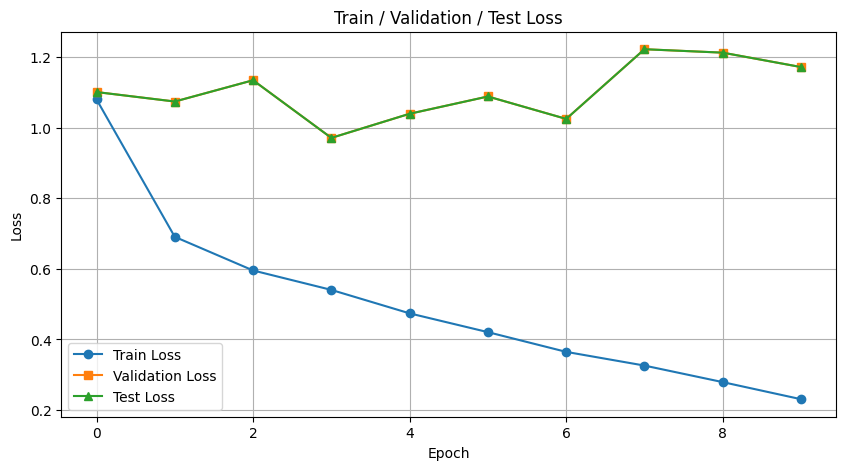

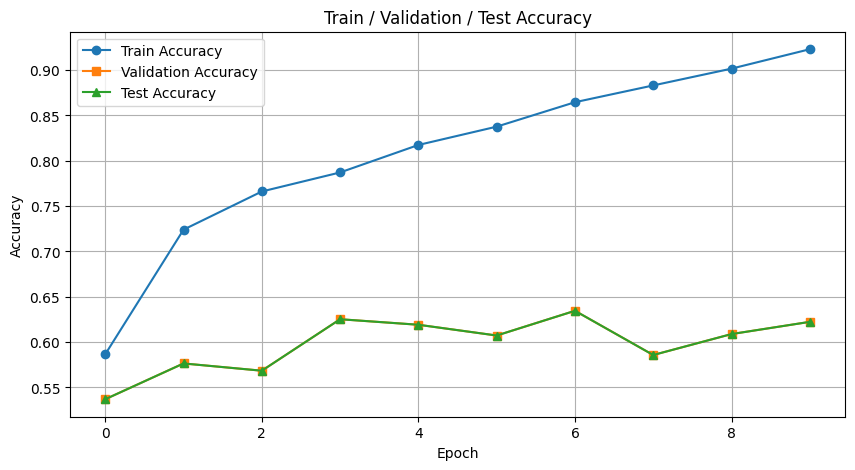

In [60]:
import matplotlib.pyplot as plt

# ---- Loss Plot ----
plt.figure(figsize=(10,5))
plt.plot(train_loss_list, label="Train Loss", marker='o')
plt.plot(val_loss_list, label="Validation Loss", marker='s')
plt.plot(test_loss_list, label="Test Loss", marker='^')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Validation / Test Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---- Accuracy Plot ----
plt.figure(figsize=(10,5))
plt.plot(train_acc_list, label="Train Accuracy", marker='o')
plt.plot(val_acc_list, label="Validation Accuracy", marker='s')
plt.plot(test_acc_list, label="Test Accuracy", marker='^')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train / Validation / Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()


Classification Report:
              precision    recall  f1-score   support

           0     0.7314    0.3703    0.4917       478
           1     0.6148    0.9827    0.7564       869
           2     0.8978    0.3241    0.4763       867
           3     0.5354    0.6955    0.6050       903

    accuracy                         0.6224      3117
   macro avg     0.6948    0.5931    0.5823      3117
weighted avg     0.6884    0.6224    0.5940      3117



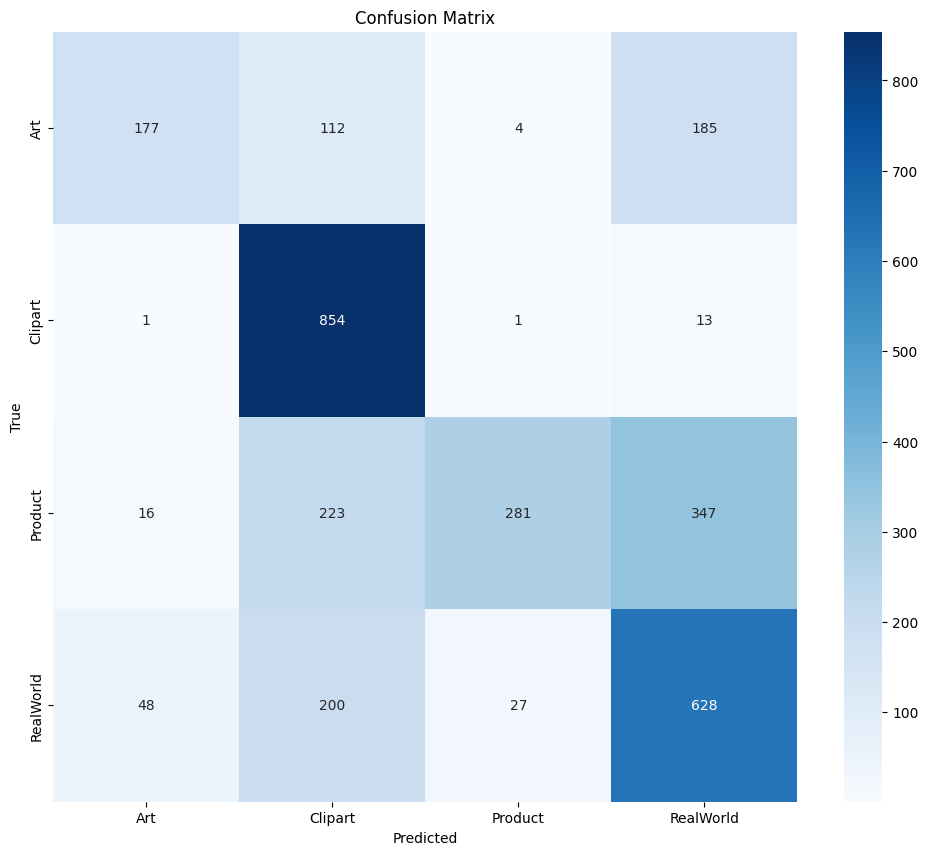

In [63]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Get all predictions and true labels
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        y_hat = model(x)
        preds = y_hat.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

# Classification Report
print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Class names for OfficeHome
class_names = ["Art", "Clipart", "Product", "RealWorld"]

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

